In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xarray as xr
import scanpy as sc
import anndata as ad
from pathlib import Path
import muon as mu 

import sys
sys.path.append('/oak/stanford/groups/engreitz/Users/ymo/NMF_re-inplementing/Script/pipeline')

from Correlation_clustermap_heatmap import *


## Functions & Data

In [70]:
# Functions 

# For graphing clustermap given corr matrix
def graph_cluster(matrix, folder_name, file_name, method):
 
    palette = sns.color_palette("tab10", n_colors=matrix.columns.nunique())
    lut = dict(zip(matrix.columns.unique(), palette))
    row_colors = matrix.columns.map(lut)
    
    sns.set_theme(style="white")               # optional aesthetics
    g = sns.clustermap(
            matrix,
            cmap="vlag",                       # diverging palette centred at 0
            linewidths=.5,                     # grid lines
            center=0,                          # keep 0 in the middle of the colour range
            metric="euclidean",                # distance metric for clustering
            method= method,                  # linkage method
            figsize=(10, 10),                   # size in inches
            row_colors=row_colors,
            col_colors = row_colors,
            row_cluster=True,
            col_cluster=True
    )

    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90)
    plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)
    plt.title(file_name + " " + method)

    plt.show()

    g.savefig(f"{folder_name}/{file_name}_{method}.png")
    
    return g
    
# For compile all runs information 
def get_run_info(folder_name, file_name, adata_var_names, run = 10, k_by_gene = True):
    
    matrices = []

    name = file_name.split('_')[1] + file_name.split('_')[2] + file_name.split('_')[5]

    for i in range(1,run+1): 
        matrix = np.load(f"{folder_name}/{file_name}_{i}.npy") 
         
        if k_by_gene: 
            row_names = [f"run{i}_{name}"  for j in range(1,run+1)]
            df = pd.DataFrame(matrix, index=row_names, columns = adata_var_names.index)
        else:
            col_names = [f"run{i}_{name}"  for j in range(1,run+1)]
            df = pd.DataFrame(matrix, columns=col_names)
            

        matrices.append(df)

    axis = 0 if k_by_gene else 1
    stacked_matrices =  pd.concat(matrices, axis= axis) 
    
    return stacked_matrices

# for compute H matrix corr
def cell_by_K_corr(matrix1,matrix2):
    
    if matrix2.shape != matrix2.shape:
        print("dim is different")
        return 
    
    num_columns = matrix1.shape[1]
    column_correlations = []
    
    for i in range(num_columns):
        for j in range(num_columns):
            
            # Calculate the correlation coefficient between the i-th column of matrix1 and j-th column of matrix2
            correlation = np.corrcoef(matrix1.iloc[:,i], matrix2.iloc[:,j])[0, 1]
            column_correlations.append(correlation)
            
    df = pd.DataFrame(np.array(column_correlations).reshape(num_columns, num_columns), columns = matrix2.columns,
                     index = matrix1.columns)
    return df

# For compute W matrix corr
def k_by_gene_corr(matrix1,matrix2):
    
    if matrix2.shape != matrix2.shape:
        print("dim is different")
        return 
    
    num_columns = matrix1.shape[0]
    column_correlations = []
    
    for i in range(num_columns):
        for j in range(num_columns):
            
            # Calculate the correlation coefficient between the i-th row of matrix1 and j-th row of matrix2
            correlation = np.corrcoef(matrix1.iloc[i,:], matrix2.iloc[j,:])[0, 1]
            column_correlations.append(correlation)
            
    df = pd.DataFrame(np.array(column_correlations).reshape(num_columns, num_columns), columns = matrix2.index,
                     index = matrix1.index)
            
    return df

# generate matrix with each entry overlap/300 
def top_genes_overlap(matrix1, matrix2, gene_num = 300):
    
    # check dim 
    if matrix1.shape != matrix2.shape:
        print("Different dim")
        return 
    
    # find out top x genes in each k
    top_genes_1 = matrix1.apply(lambda row: row.nlargest(gene_num).index.tolist(), axis=1)
    top_genes_2 = matrix2.apply(lambda row: row.nlargest(gene_num).index.tolist(), axis=1)

    
    n_k = (top_genes_1.shape[0])
    overlap = np.zeros((n_k, n_k), dtype=float)
    gene_shared_list = pd.Series(dtype=object)

    # generate overlap matrix 
    for i in range(n_k):
        for j in range(n_k):
            s = len(set(top_genes_1.iloc[i]) & set(top_genes_2.iloc[j]))/gene_num

            # compose a shared gene matrix
            gene_shared = list(set(top_genes_1.iloc[i]) & set(top_genes_2.iloc[j]))
            name = f"{top_genes_1.index[i]} VS {top_genes_2.index[j]}"
            gene_shared_list.at[name] = gene_shared 
            
            overlap[i, j] = s

    overlap_df = pd.DataFrame(overlap,
                              index=matrix1.index,
                              columns=matrix2.index)
    
    return overlap_df, top_genes_1,top_genes_2, gene_shared_list

# graph heatmap
def graph_heatmap(g, r, c, folder_name, file_name, num_gene = 300, sorted = False):

    mat = g.data2d.to_numpy() * num_gene

    assert mat.shape[0] % r == 0 and mat.shape[1] % c == 0, \
           "Rows/cols must divide evenly by block size."

    n_row_blocks = mat.shape[0] // r
    n_col_blocks = mat.shape[1] // c

    blocks = (mat.reshape(n_row_blocks, r, n_col_blocks, c)
            .swapaxes(1, 2)              
            .reshape(-1, r, c))

    block_means = (blocks.mean(axis=(1, 2))).astype(int)
    plt.figure(figsize=(12, 8))
    sns.heatmap(block_means.reshape(10,10),annot=True, cmap='inferno_r',fmt='d')        
    plt.title("Heatmap for matching programs " + file_name)

    g.savefig(f"{folder_name}/{file_name}.png")
 
    plt.show()

    # Sorted heatmap
    if sorted: 
        matrix = block_means.reshape(10,10).tolist()

        for i in range(len(matrix)):
            max_index = matrix[i].index(max(matrix[i]))
            # Swap max element with the diagonal element
            matrix[i][i], matrix[i][max_index] = matrix[i][max_index], matrix[i][i]

        plt.figure(figsize=(12, 8))
        sns.heatmap(np.array(matrix).reshape(r,c),annot=True, cmap='inferno_r',fmt='d')        
        plt.title("Sorted Heatmap for matching programs " + file_name)

        g.savefig(f"{folder_name}/{file_name}_sorted.png")
 
        plt.show()

# make excel sheets with selected tops and shared genes across programs
def make_gene_list_excel(folder_name, file_name, gene_list_1, gene_list_2, gene_list_shared):

    def make_df(list):
        #sort gene
        df = list.apply( lambda row: sorted([x for x in row if pd.notna(x)]))

        df = df.apply(pd.Series)

        return df.transpose()

    gene_list_1 =  make_df(gene_list_1)
    gene_list_2 =  make_df(gene_list_2)
    gene_list_shared = make_df(gene_list_shared)


    with pd.ExcelWriter(f'{folder_name}/{file_name}.xlsx') as writer:
        gene_list_1.to_excel(writer, sheet_name = "gene list 1", index=True)
        gene_list_2.to_excel(writer, sheet_name = "gene list 2", index=True)
        gene_list_shared.to_excel(writer, sheet_name = "gene list shared", index=True)

# compare corr within package in multiple runs
def within_package_corr_clustermap(folder_name_input, file_name_input, folder_name_output, file_name_output, adata_var_names, cluster_method, num_run = 10, k_by_gene = True):

    # collect 10 runs for k by gene (H)
    combined = get_run_info(folder_name_input, file_name_input, adata_var_names, run = num_run, k_by_gene = k_by_gene)

    if k_by_gene: 
        # correlatopn  
        matrix_combined=  k_by_gene_corr(combined,combined)
    else:
        # ccorrelatopn 
        matrix_combined = cell_by_k_corr(combined,combined)       


    # graph correlation matrix
    g = graph_cluster(matrix_combined, folder_name = folder_name_output, file_name = file_name_output, method = cluster_method)

    return g

# compare corr across package in multiple runs
def acorss_package_corr_clustermap(folder_name_input, file_name_input_pka1,  file_name_input_pkg2, folder_name_output, file_name_output, adata_var_names, cluster_method, num_run = 10, k_by_gene = True):

    # collect 10 runs for k by gene (H)
    combined_pkg_1 = get_run_info(folder_name_input, file_name_input_pka1, adata_var_names, run = num_run, k_by_gene = k_by_gene)
    combined_pkg_2 = get_run_info(folder_name_input, file_name_input_pkg2, adata_var_names, run = num_run, k_by_gene = k_by_gene)

    if k_by_gene: 
        # correlatopn  
        matrix_combined=  k_by_gene_corr(combined_pkg_1,combined_pkg_2)
    else:
        # ccorrelatopn 
        matrix_combined = cell_by_k_corr(combined_pkg_1,combined_pkg_2)       


    # graph correlation matrix
    g = graph_cluster(matrix_combined, folder_name = folder_name_output, file_name = file_name_output, method = cluster_method)

    return g

# compare 300 gene within package in multiple runs
def within_package_overlap_cluster(folder_name_input, file_name_input, folder_name_output, file_name_output, adata_var_names, cluster_method, num_run = 10, num_gene = 300):

    # collect 10 runs for k by gene (H)
    combined = get_run_info(folder_name_input, file_name_input, adata_var_names, run = num_run, k_by_gene = True)

    # obtain top 300 genes
    top300, top_genes_1,top_genes_2, gene_shared_list = top_genes_overlap(combined, combined, gene_num = num_gene)

    # generate gene list
    make_gene_list_excel(folder_name_output +"/Data",file_name_output, top_genes_1,top_genes_2, gene_shared_list)

    # graph correlation matrix
    g = graph_cluster(top300, folder_name = folder_name_output+ "/Figures", file_name = file_name_output, method = cluster_method)

    return g

# compare 300 gene acorss package in multiple runs
def across_package_overlap_cluster(folder_name_input, file_name_input1, file_name_input2, folder_name_output, file_name_output, adata_var_names, cluster_method, num_run = 10, num_gene = 300):

    # collect 10 runs for k by gene (H)
    combined_1 = get_run_info(folder_name_input, file_name_input1, adata_var_names, run = num_run, k_by_gene = True)
    combined_2 = get_run_info(folder_name_input, file_name_input2, adata_var_names, run = num_run, k_by_gene = True)

    # obtain top 300 genes
    top300, top_genes_1,top_genes_2, gene_shared_list = top_genes_overlap(combined_1, combined_2, gene_num = num_gene)

    # generate gene list
    make_gene_list_excel(folder_name_output +"/Data",file_name_output, top_genes_1,top_genes_2, gene_shared_list)

    # graph correlation matrix
    g = graph_cluster(top300, folder_name = folder_name_output+ "/Figures",  file_name = file_name_output, method = cluster_method)

    return g



In [ ]:
# reading adata

mdata = mu.read("/oak/stanford/groups/engreitz/Users/ymo/NMF_re-inplementing/Cell_data/250_gene_rawcounts_7.16.25.h5mu")  
adata = mdata.mod['rna']
cNNMF = mdata.mod['cNMF']
adata.var_names_make_unique()

## Graph correlation

In [16]:
# 10k cells
folder_name_10_runs = "/oak/stanford/groups/engreitz/Users/ymo/NMF_re-inplementing/Results/NMF_benchmark_10_runs_random_seeds_7.29.25"
#folder_name_results = "/oak/stanford/groups/engreitz/Users/ymo/NMF_re-inplementing/NMF_correlation_top300_gene_7.30.25"

g_nmftorch_cuda_corr = within_package_corr_clustermap(folder_name_10_runs, "H_nmftorch_cuda_K10_cell10000_", folder_name_results, "H_k=10_cell=10k_run=10_nmftorch_cuda_corr", adata.var, cluster_method = "average" )
g_sk_cd_corr = within_package_corr_clustermap(folder_name_10_runs, "H_sk_cd_K10_cell10000_", folder_name_results, "H_k=10_cell=10k_run=10_sk_cd_corr",  adata.var, cluster_method = "average" )
g_combined_corr = acorss_package_corr_clustermap(folder_name_10_runs,   "H_nmftorch_cuda_K10_cell10000_", "H_sk_cd_K10_cell10000_", folder_name_results, "H_k=10_cell=10k_run=10_nmfVSsk_corr",  adata.var, cluster_method = "average" )

FileNotFoundError: [Errno 2] No such file or directory: '/oak/stanford/groups/engreitz/Users/ymo/NMF_re-inplementing/NMF_benchmark_10_runs_random_seeds_7.29.25/H_nmftorch_cuda_K10_cell10000__1.npy'

/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


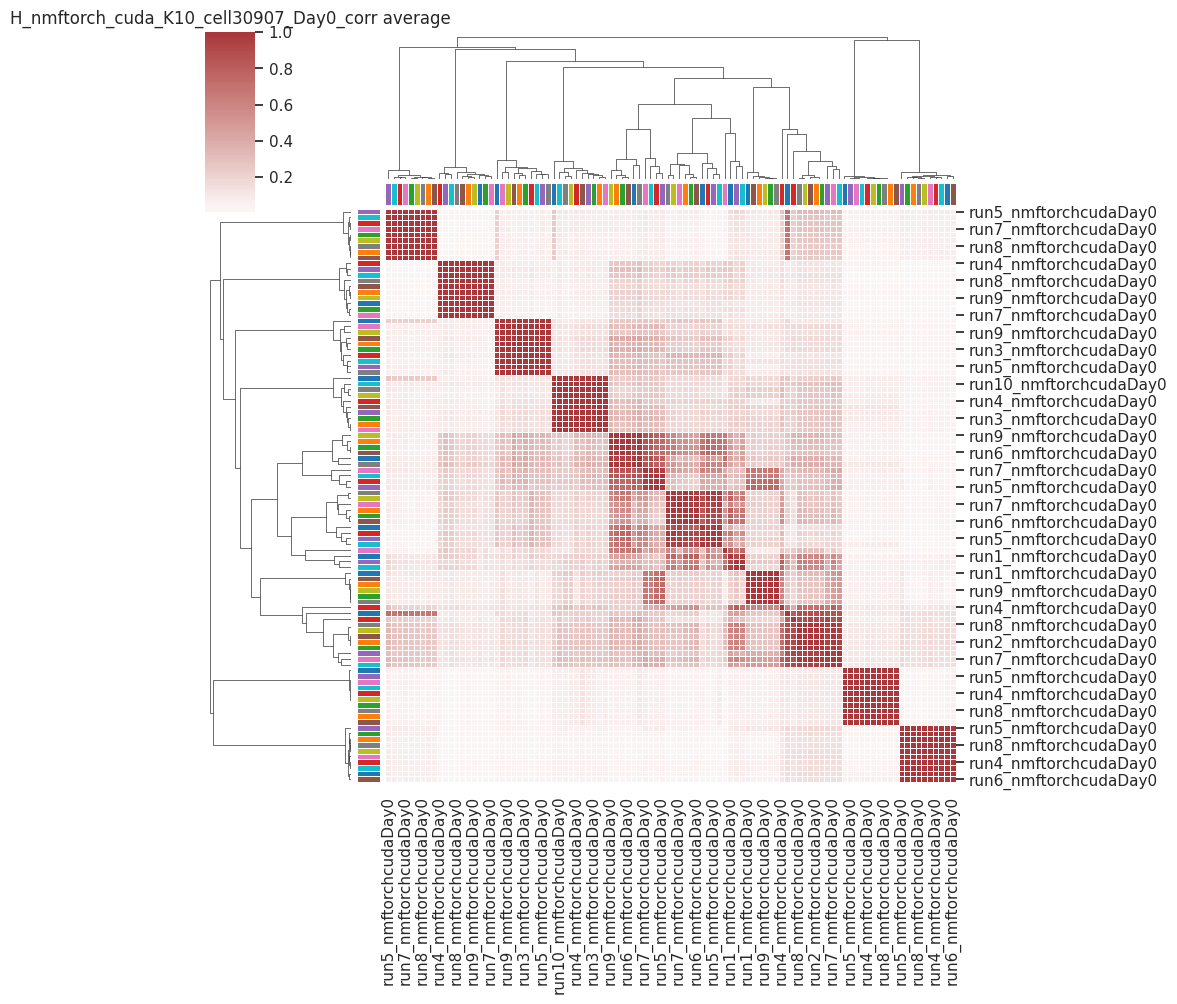

/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


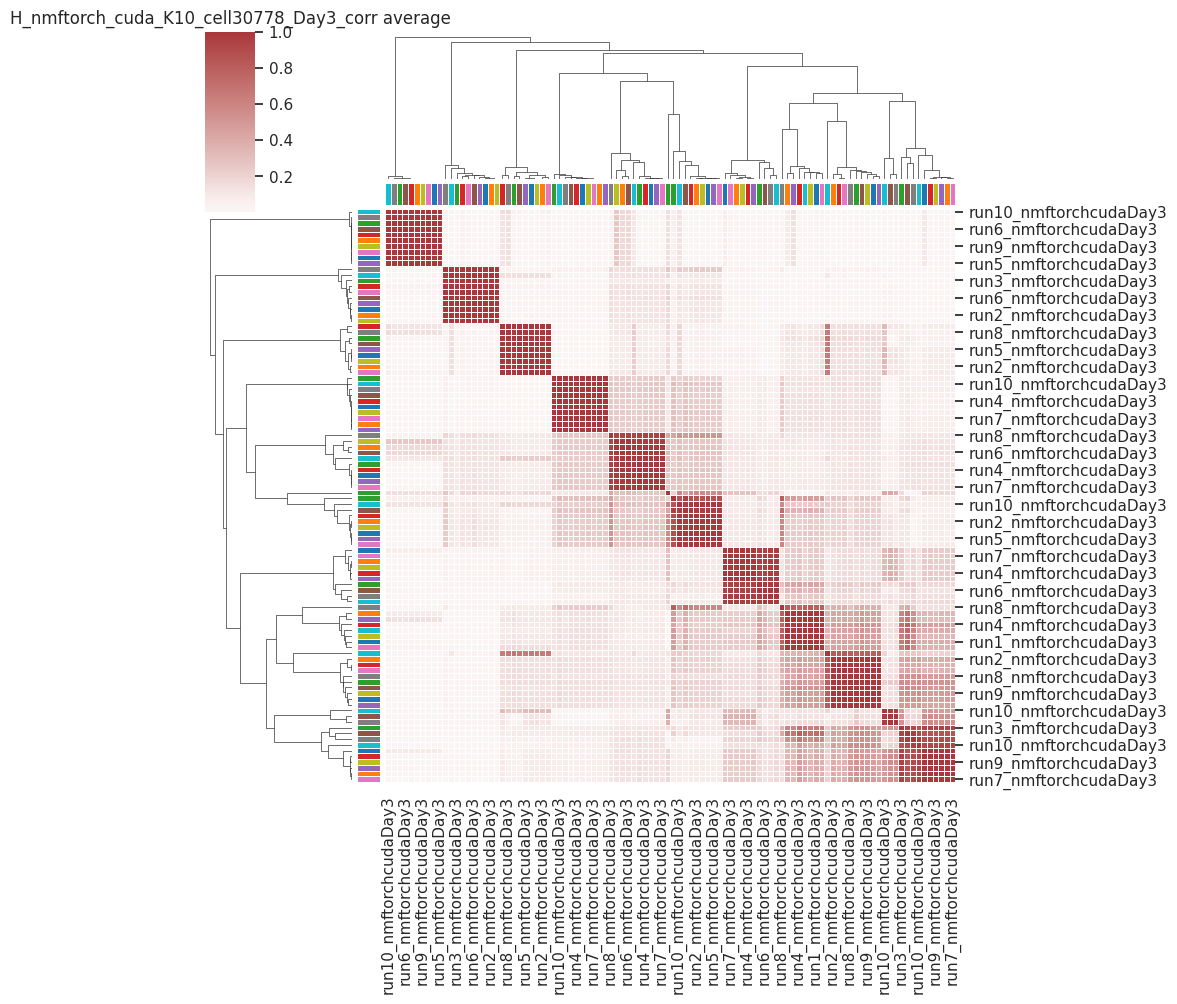

/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


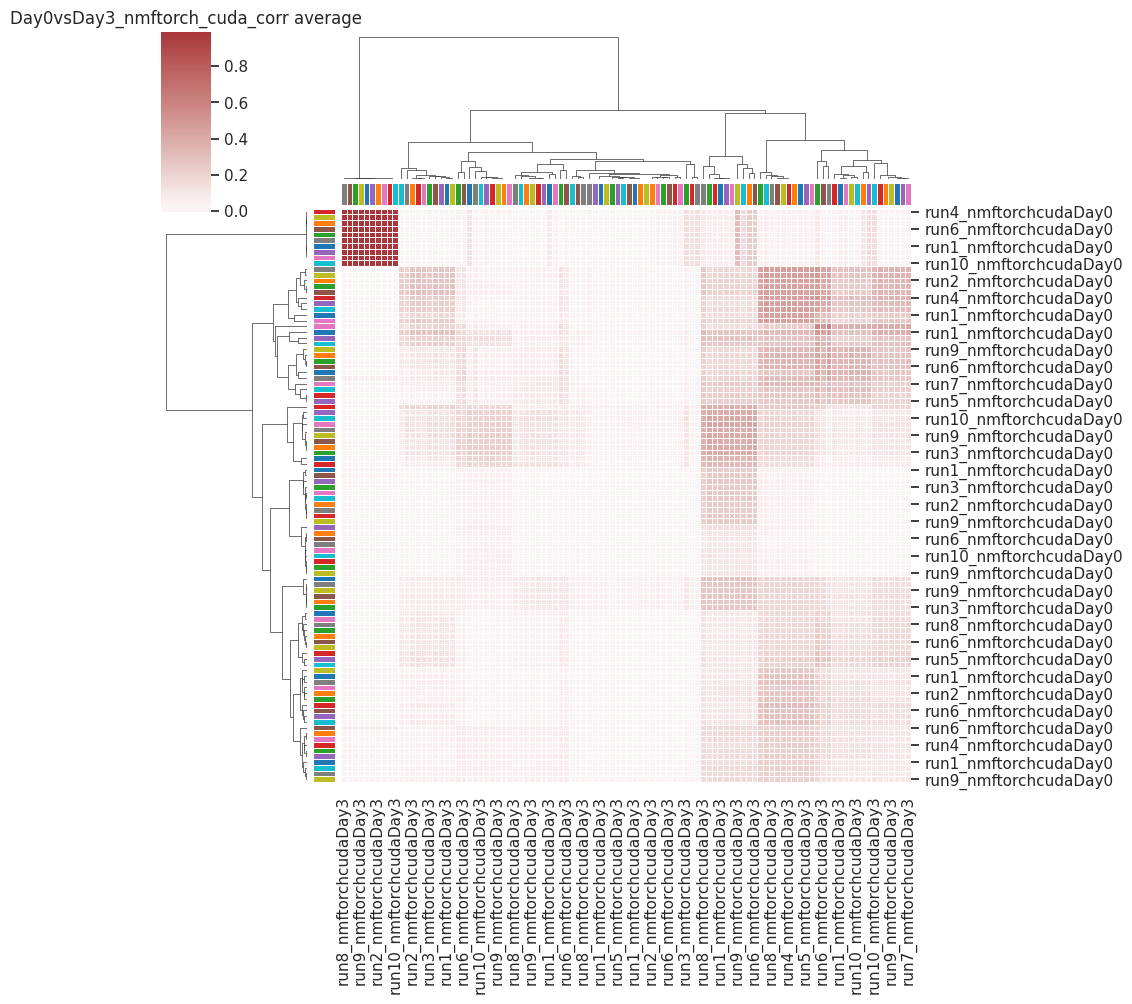

/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


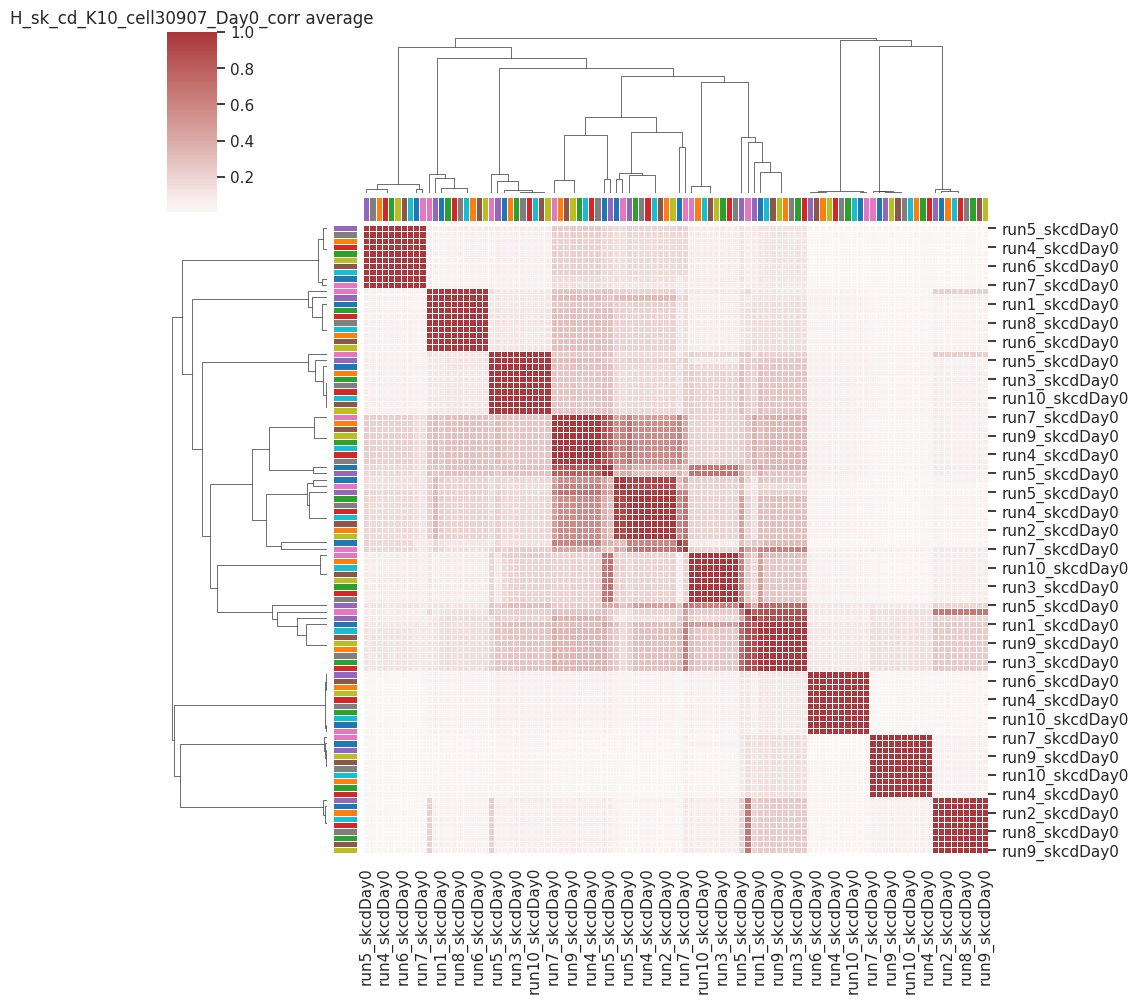

/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


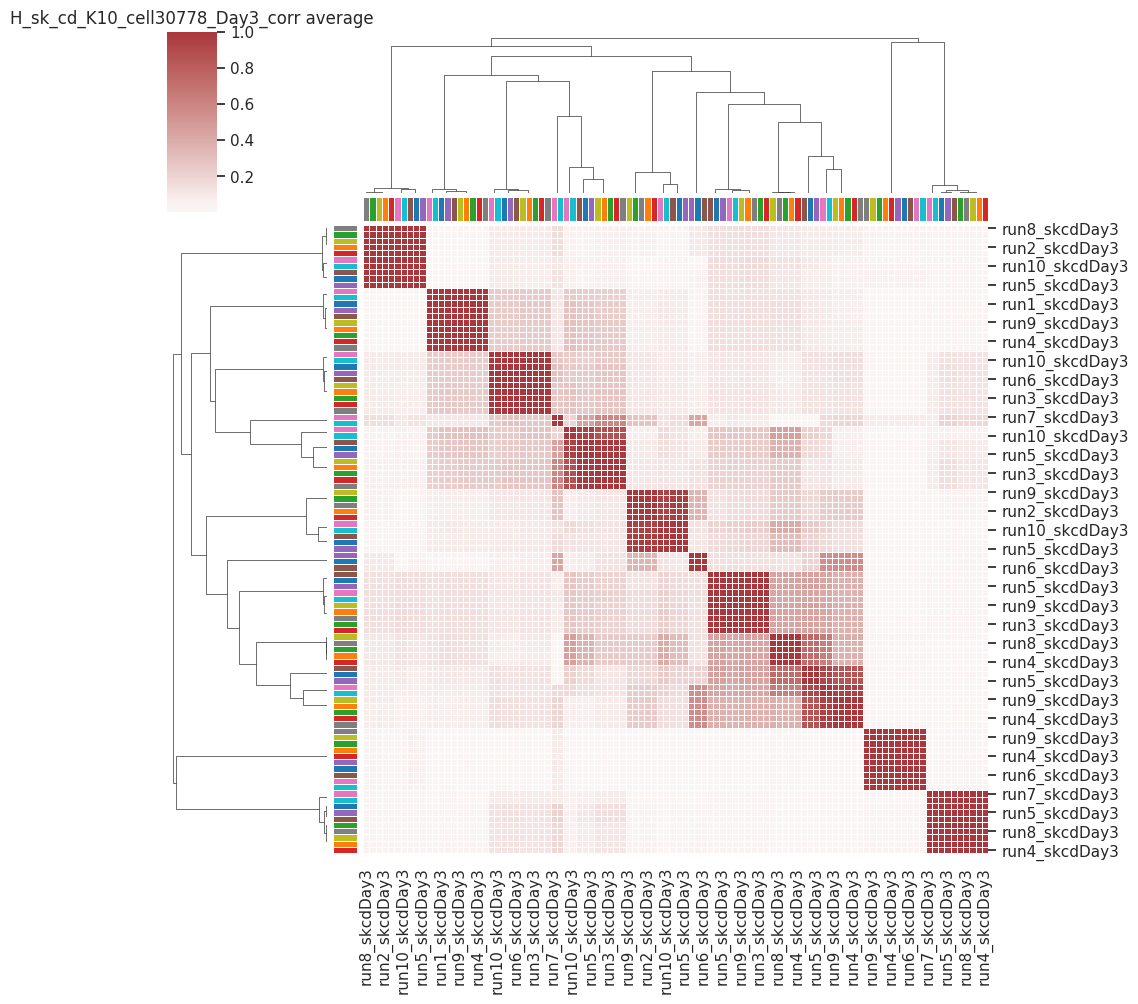

/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


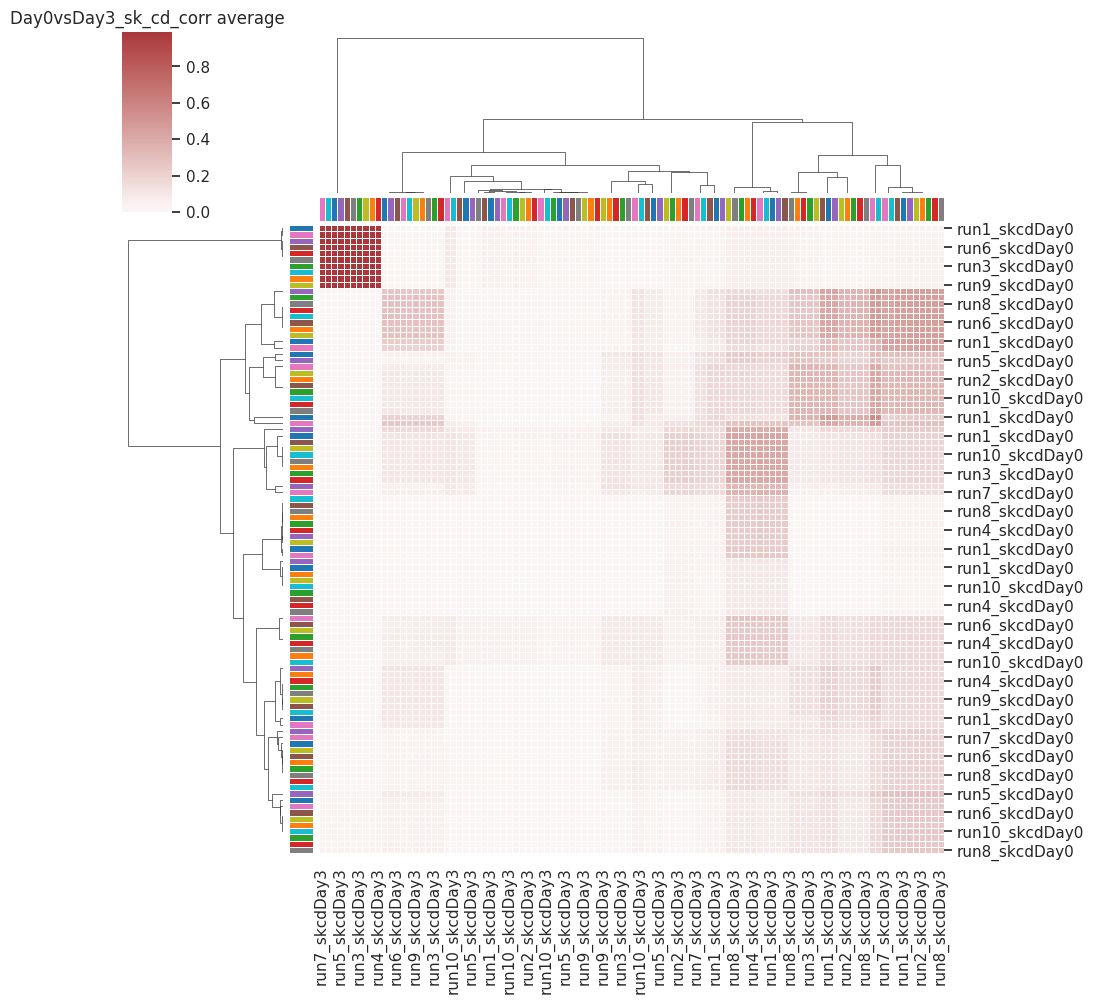

In [77]:
# D0 and D3 cells 
folder_name_input = "/oak/stanford/groups/engreitz/Users/ymo/NMF_re-inplementing/NMF_benchmark_10_runs_random_seeds_D0+D3_7.30.25" 
folder_name_output = "/oak/stanford/groups/engreitz/Users/ymo/NMF_re-inplementing/NMF_correlation_top300_gene_7.30.25"

g_nmftorch_cuda_D0_corr = within_package_corr_clustermap(folder_name_input, "H_nmftorch_cuda_K10_cell30907_Day0", folder_name_output, "H_nmftorch_cuda_K10_cell30907_Day0_corr", adata.var, cluster_method = "average" )
g_nmftorch_cuda_D3_corr = within_package_corr_clustermap(folder_name_input, "H_nmftorch_cuda_K10_cell30778_Day3", folder_name_output, "H_nmftorch_cuda_K10_cell30778_Day3_corr", adata.var, cluster_method = "average" )
g_nmftorch_cuda_D0_D3_corr = acorss_package_corr_clustermap(folder_name_input,  "H_nmftorch_cuda_K10_cell30907_Day0", "H_nmftorch_cuda_K10_cell30778_Day3", folder_name_output, "Day0vsDay3_nmftorch_cuda_corr",  adata.var, cluster_method = "average" )


g_sk_cd_D0_corr = within_package_corr_clustermap(folder_name_input, "H_sk_cd_K10_cell30907_Day0", folder_name_output, "H_sk_cd_K10_cell30907_Day0_corr", adata.var, cluster_method = "average" )
g_sk_cd_D3_corr = within_package_corr_clustermap(folder_name_input, "H_sk_cd_K10_cell30778_Day3", folder_name_output, "H_sk_cd_K10_cell30778_Day3_corr", adata.var, cluster_method = "average" )
g_sk_cd_D0_D3_corr = acorss_package_corr_clustermap(folder_name_input,  "H_sk_cd_K10_cell30907_Day0", "H_sk_cd_K10_cell30778_Day3", folder_name_output, "Day0vsDay3_sk_cd_corr",  adata.var, cluster_method = "average" )

/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


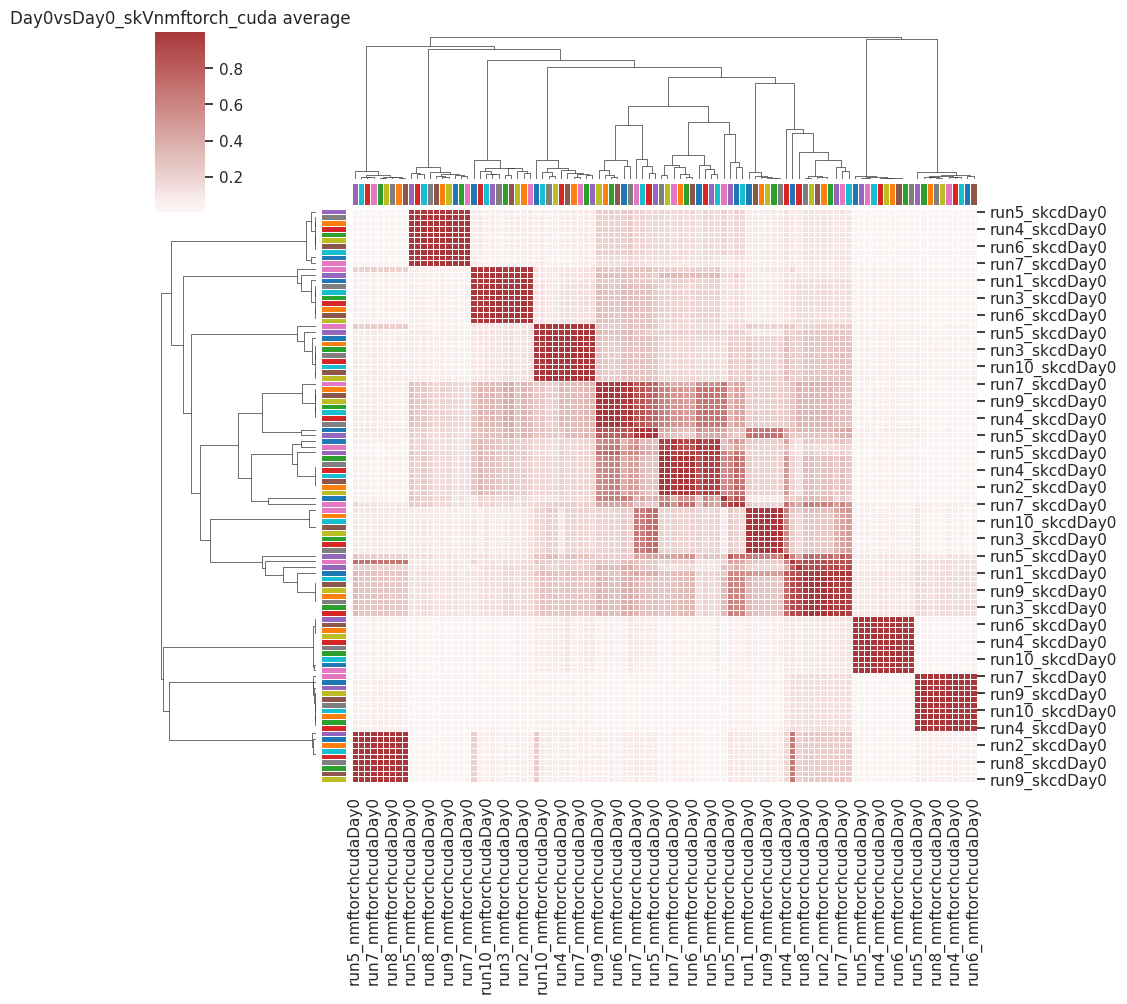

/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


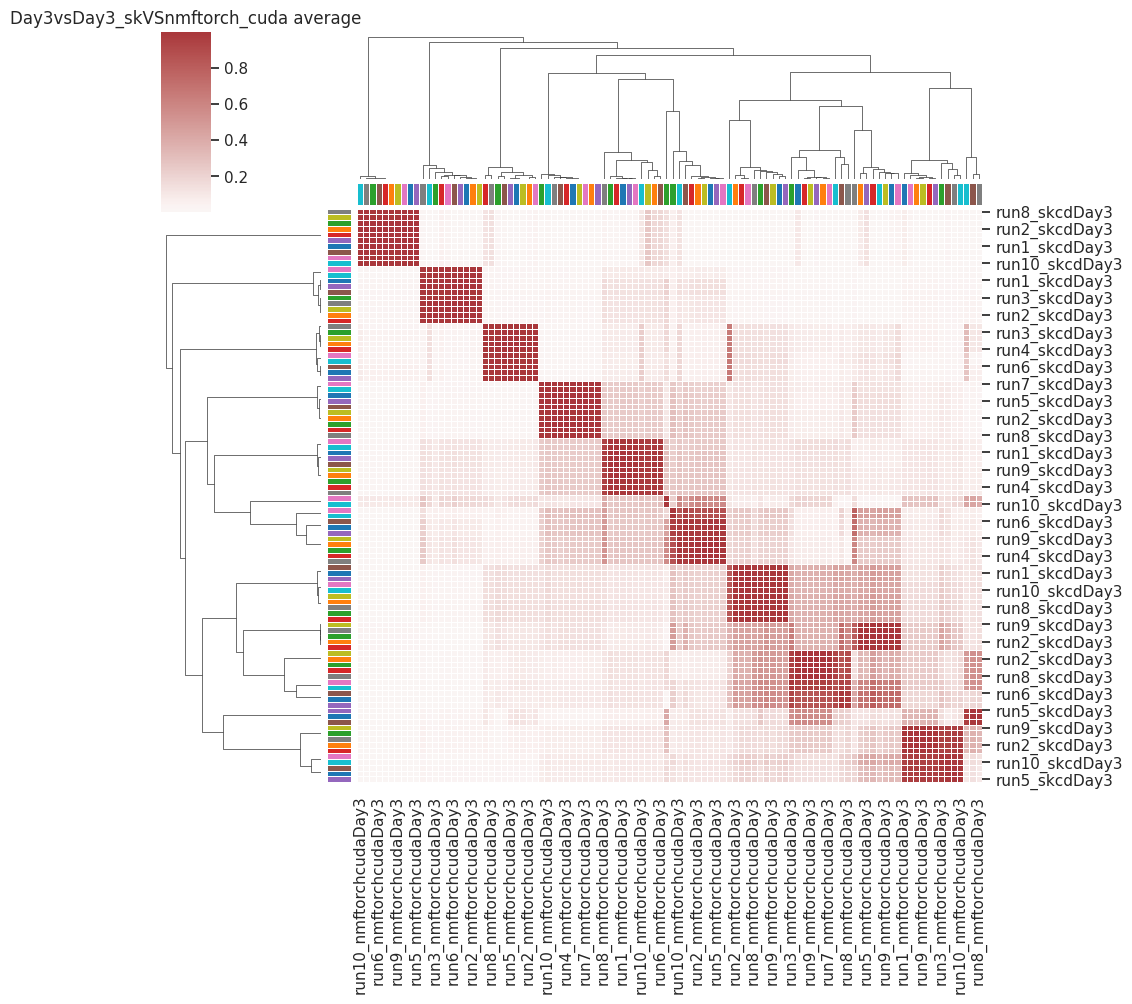

In [51]:

g_nmftorch_D0_sk_D0 = acorss_package_corr_clustermap(folder_name_input,  "H_sk_cd_K10_cell30907_Day0", "H_nmftorch_cuda_K10_cell30907_Day0", folder_name_results_figures, "Day0vsDay0_skVSnmftorch_cuda_corr",  adata.var, cluster_method = "average" )
g_nmftorch_D3_sk_D3 = acorss_package_corr_clustermap(folder_name_input,  "H_sk_cd_K10_cell30778_Day3", "H_nmftorch_cuda_K10_cell30778_Day3", folder_name_results_figures, "Day3vsDay3_skVSnmftorch_cuda_corr",  adata.var, cluster_method = "average" )

## Graph top 300 genes

/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


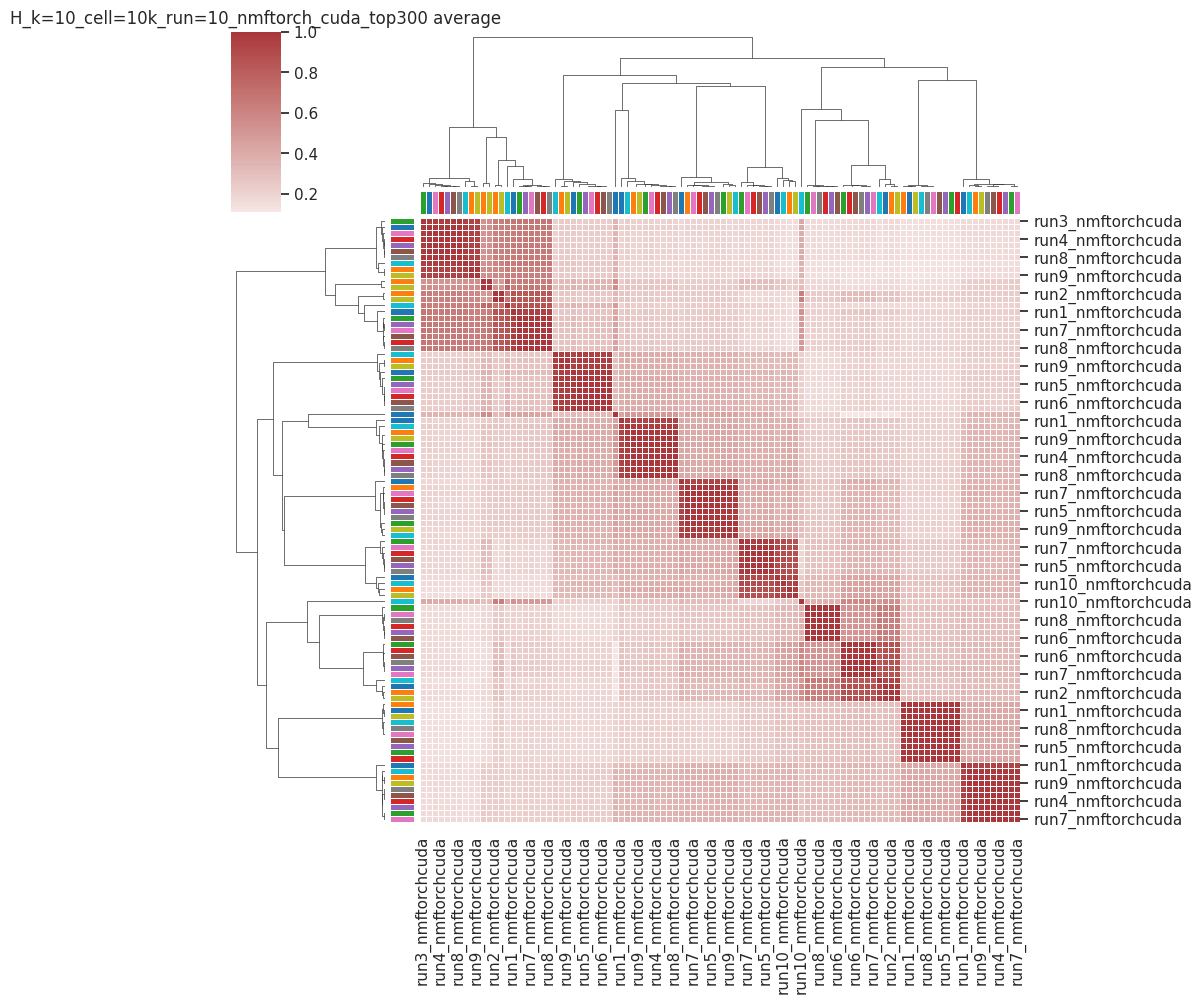

/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


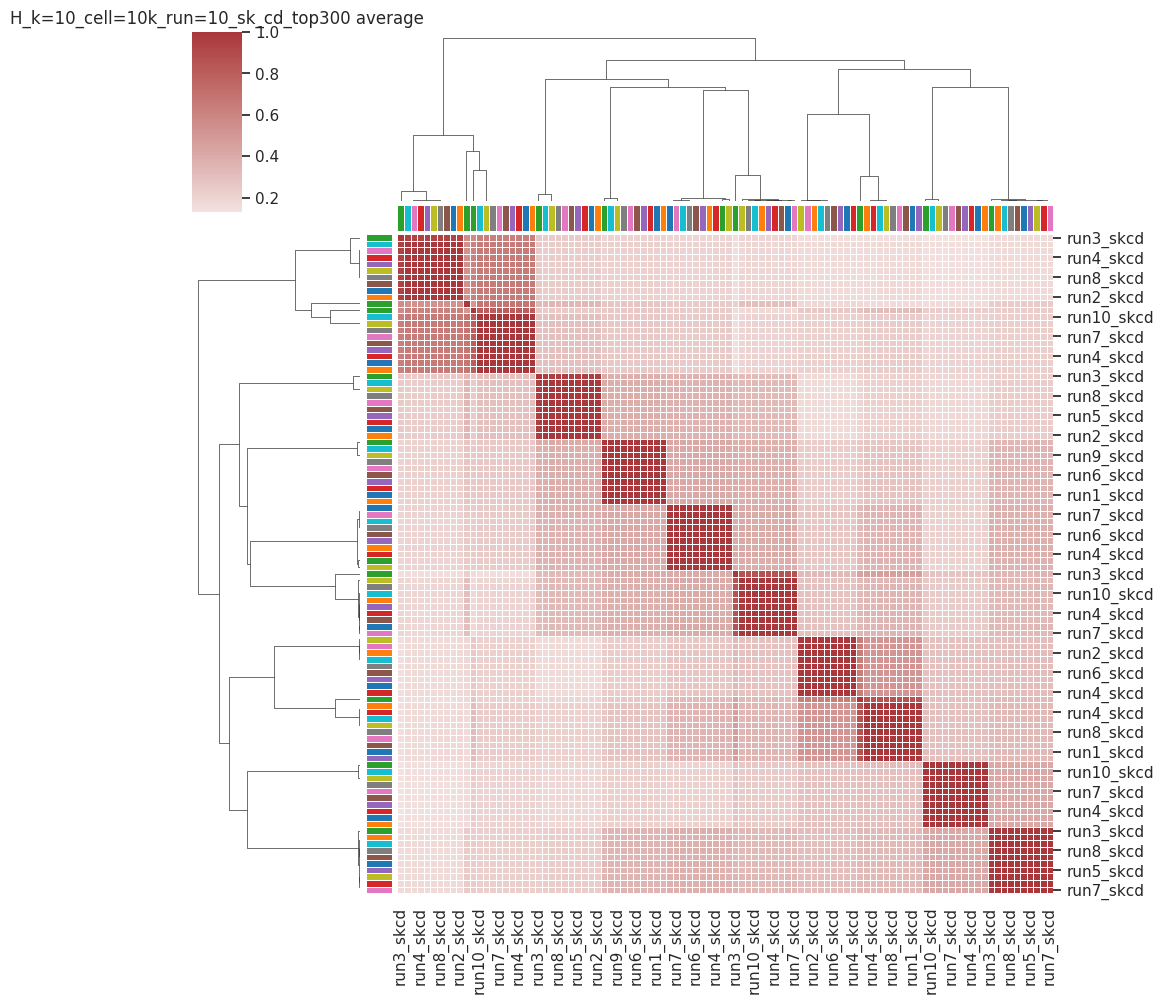

/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/users/ymo/.local/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


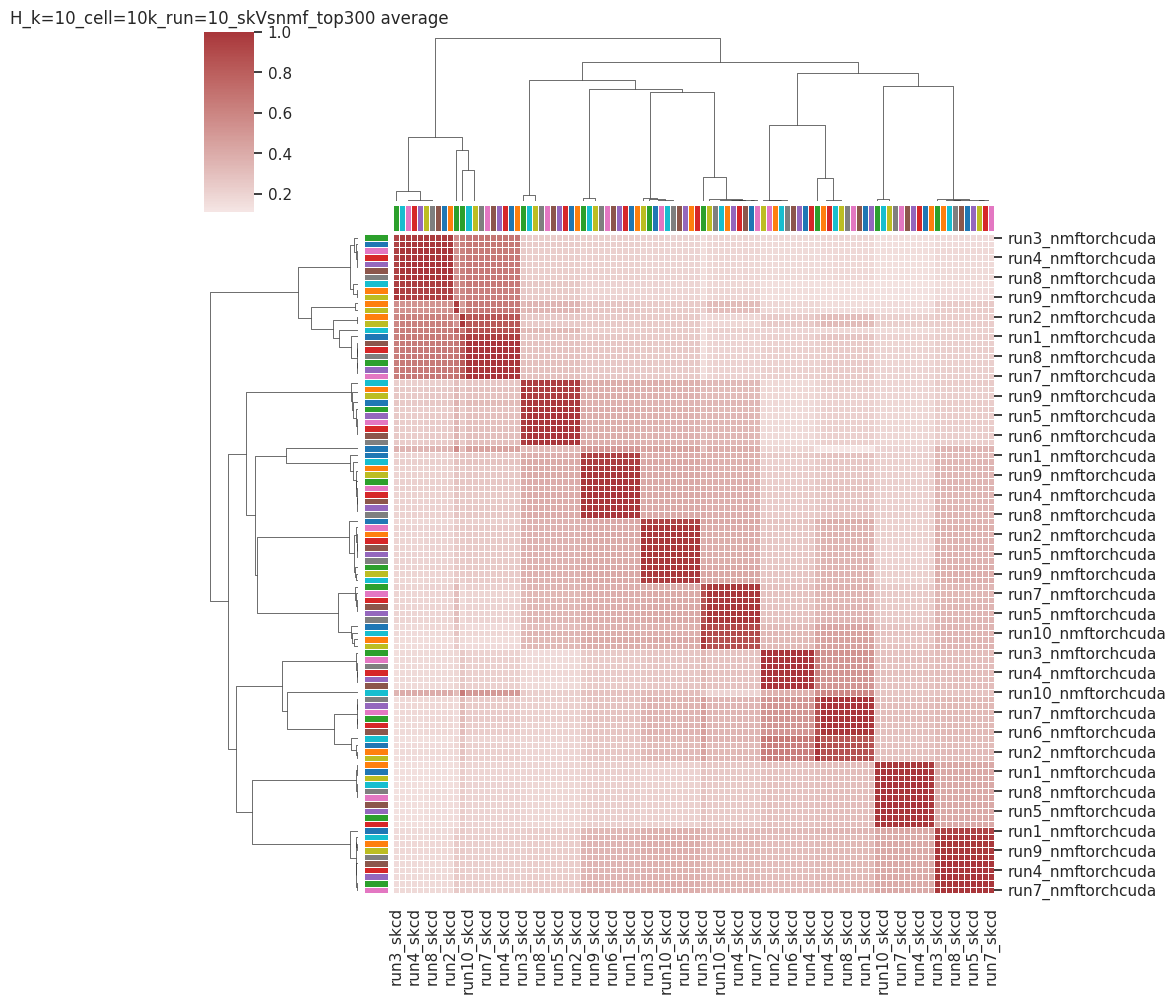

In [78]:
# 10k cells 
g_nmftorch_cuda_top300 =  within_package_overlap_cluster(folder_name_10_runs, "H_nmftorch_cuda_K10_cell10000_", folder_name_results, "H_k=10_cell=10k_run=10_nmftorch_cuda_top300",  adata.var , "average")
g_sk_cd_top300 =  within_package_overlap_cluster(folder_name_10_runs, "H_sk_cd_K10_cell10000_", folder_name_results, "H_k=10_cell=10k_run=10_sk_cd_top300",  adata.var , "average")
g_combined_top300 =  across_package_overlap_cluster(folder_name_10_runs, "H_nmftorch_cuda_K10_cell10000_", 'H_sk_cd_K10_cell10000_',folder_name_results, "H_k=10_cell=10k_run=10_skVsnmf_top300",  adata.var , "average")

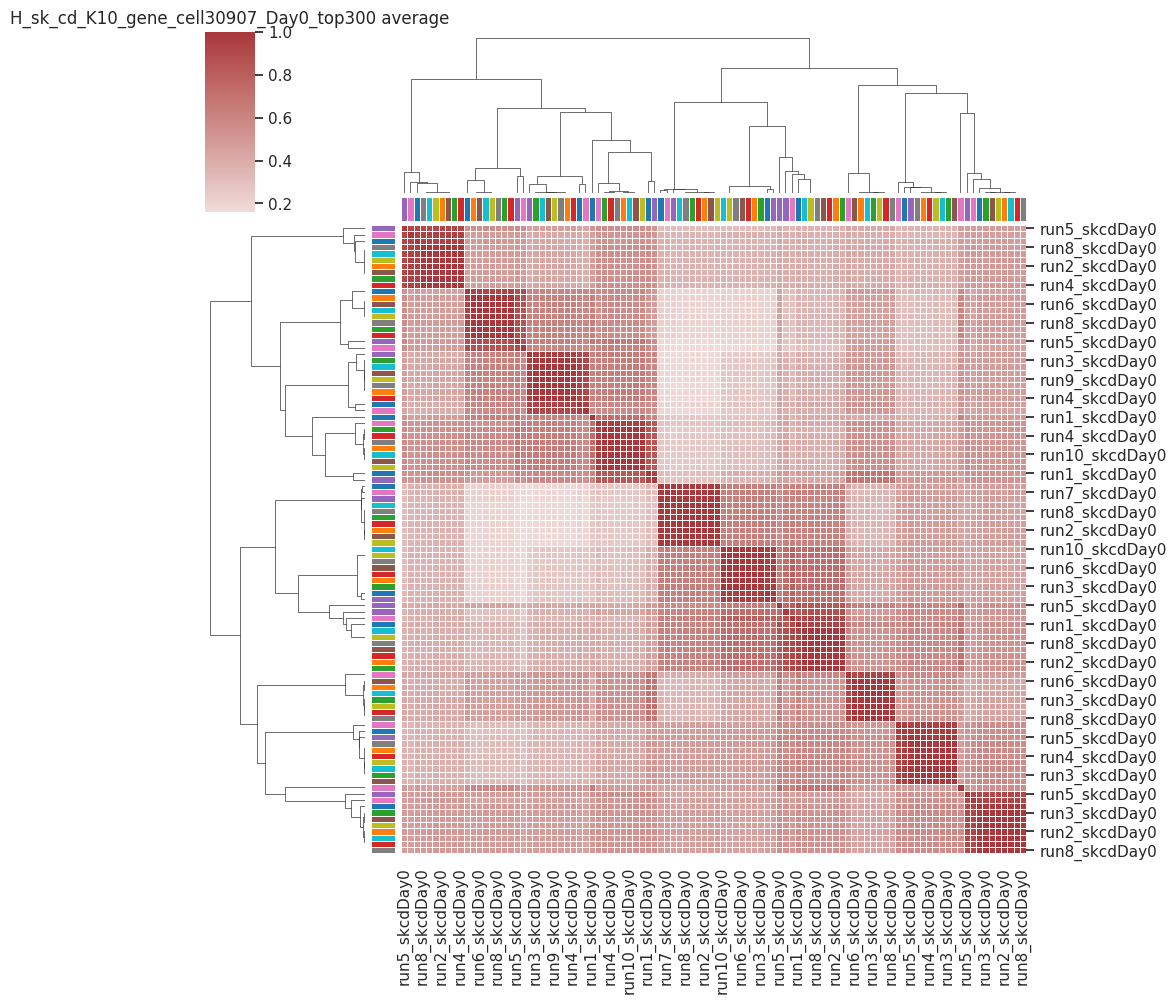

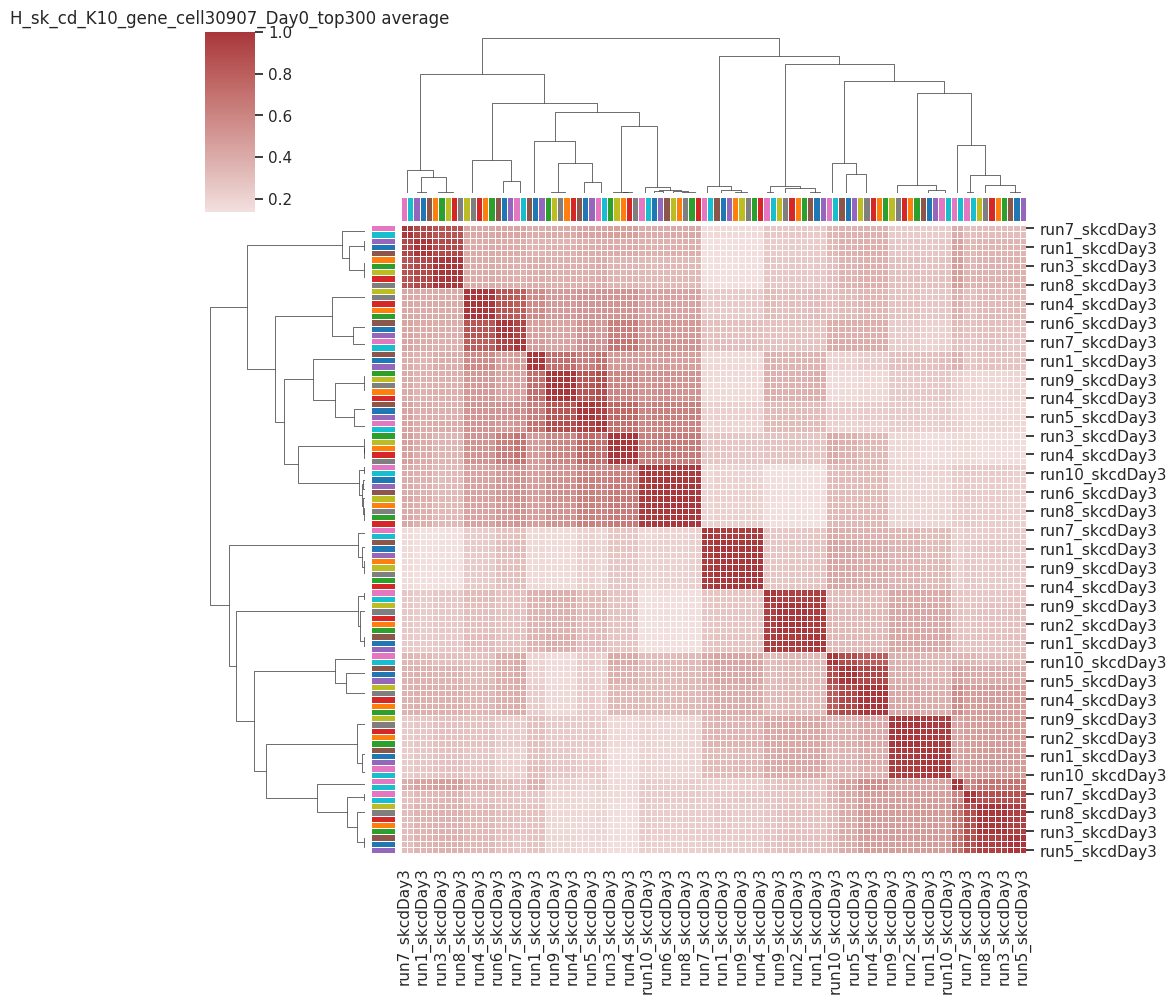

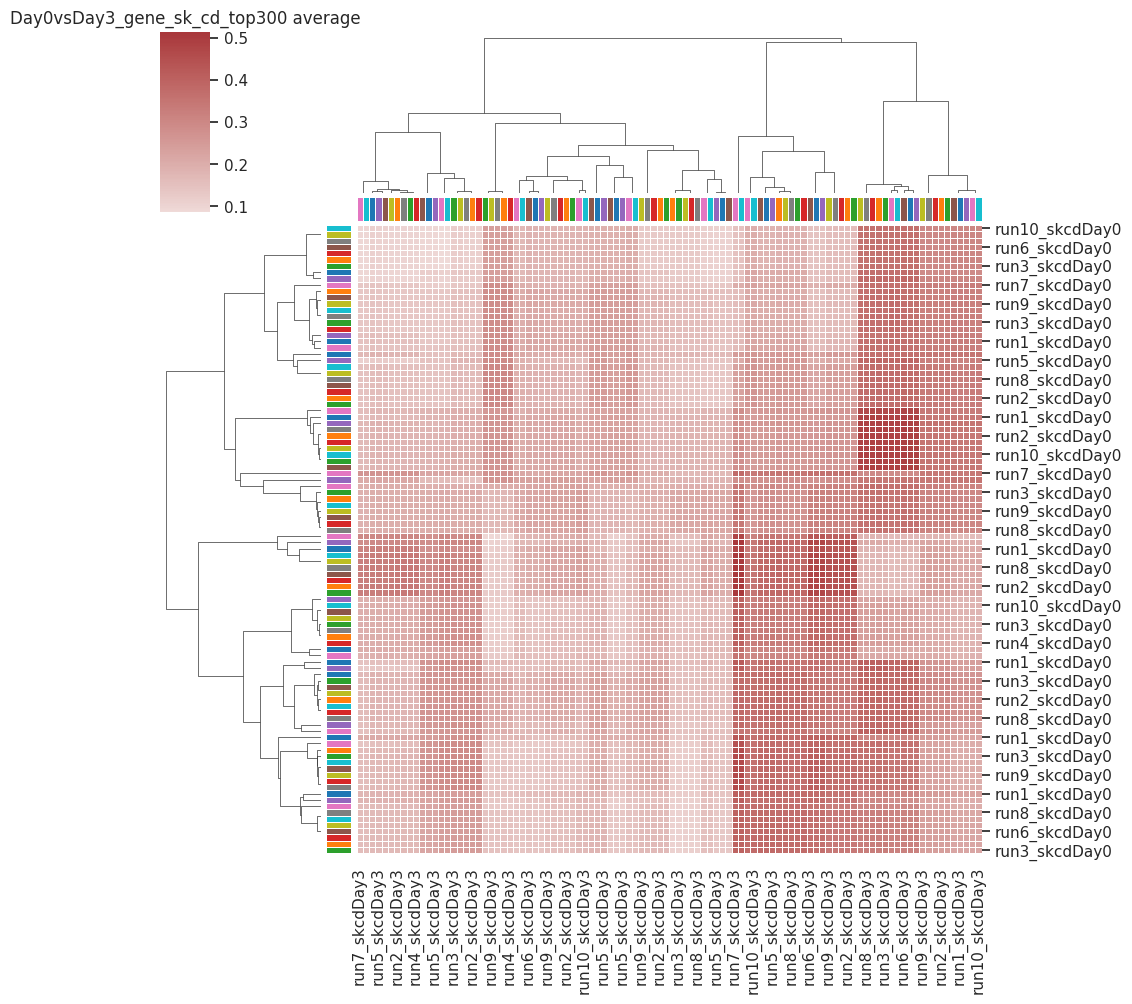

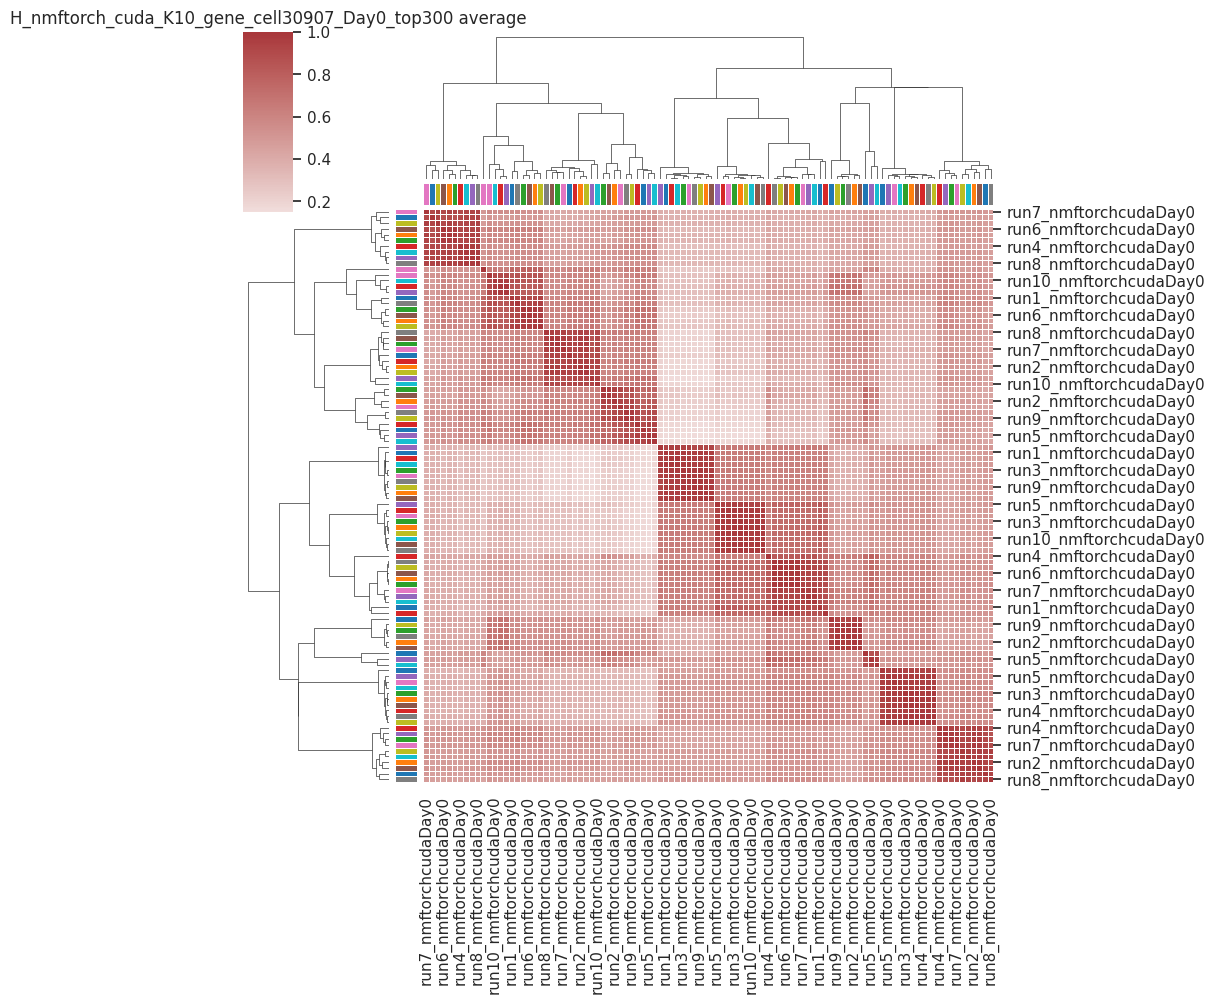

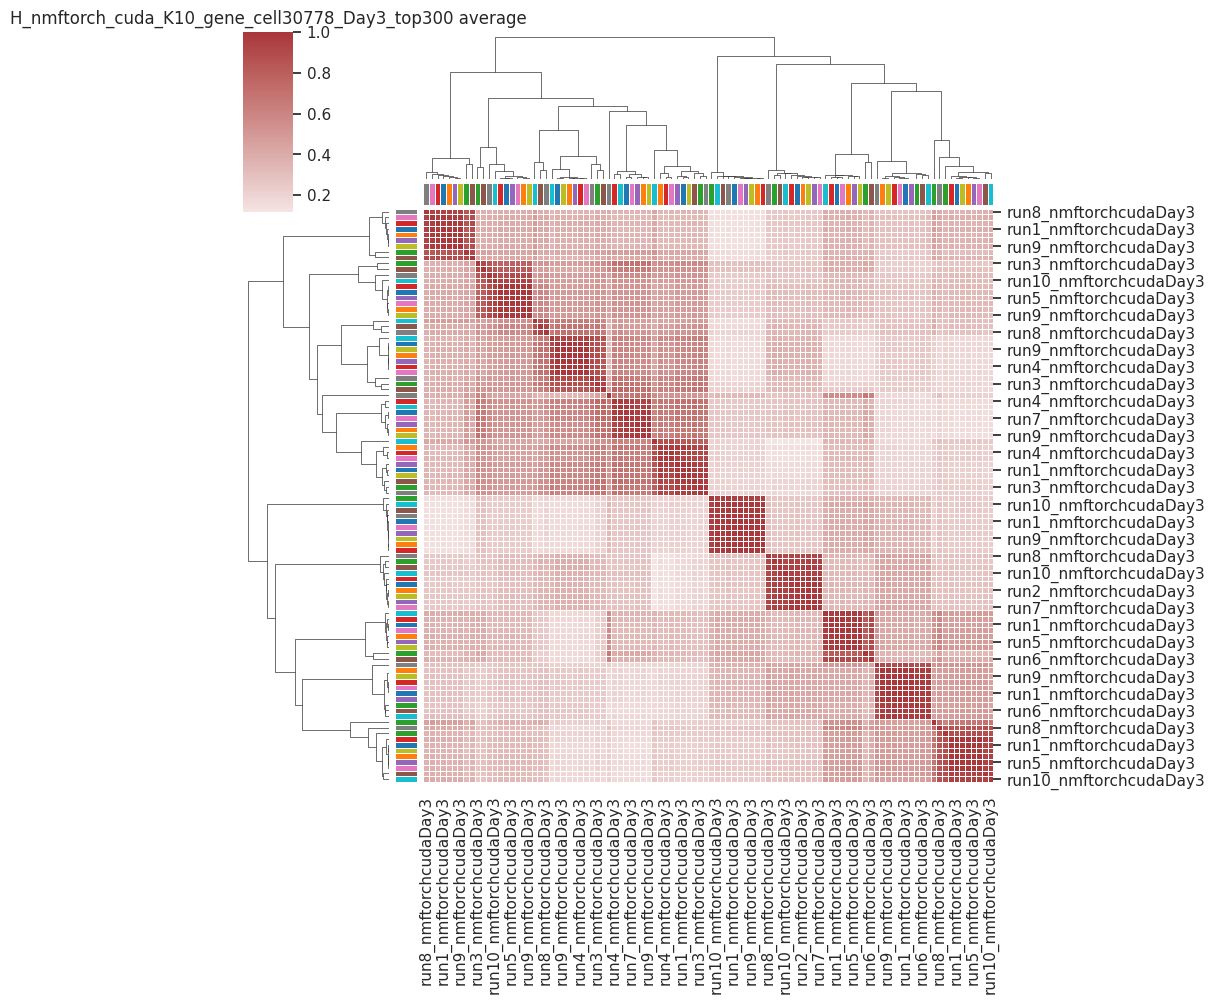

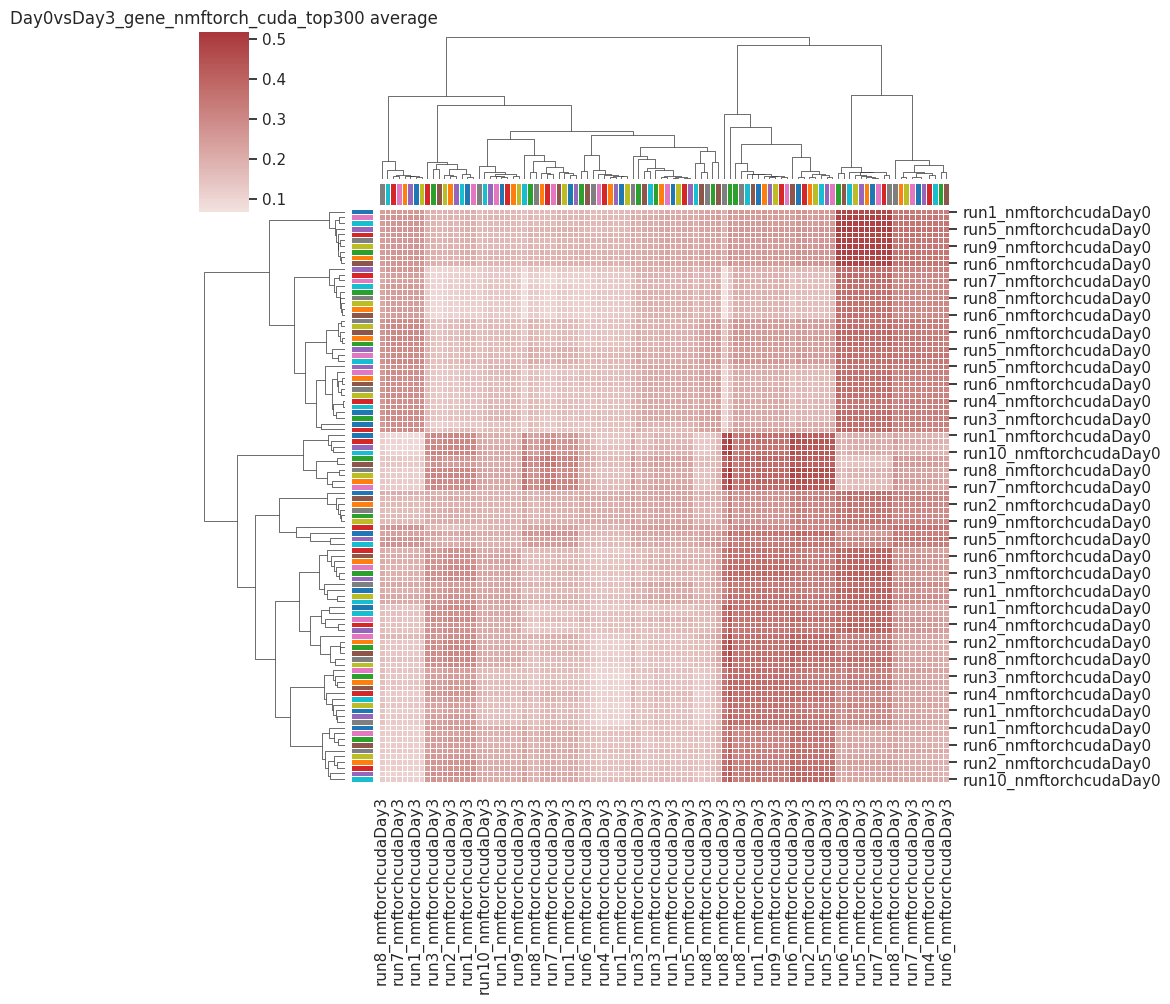

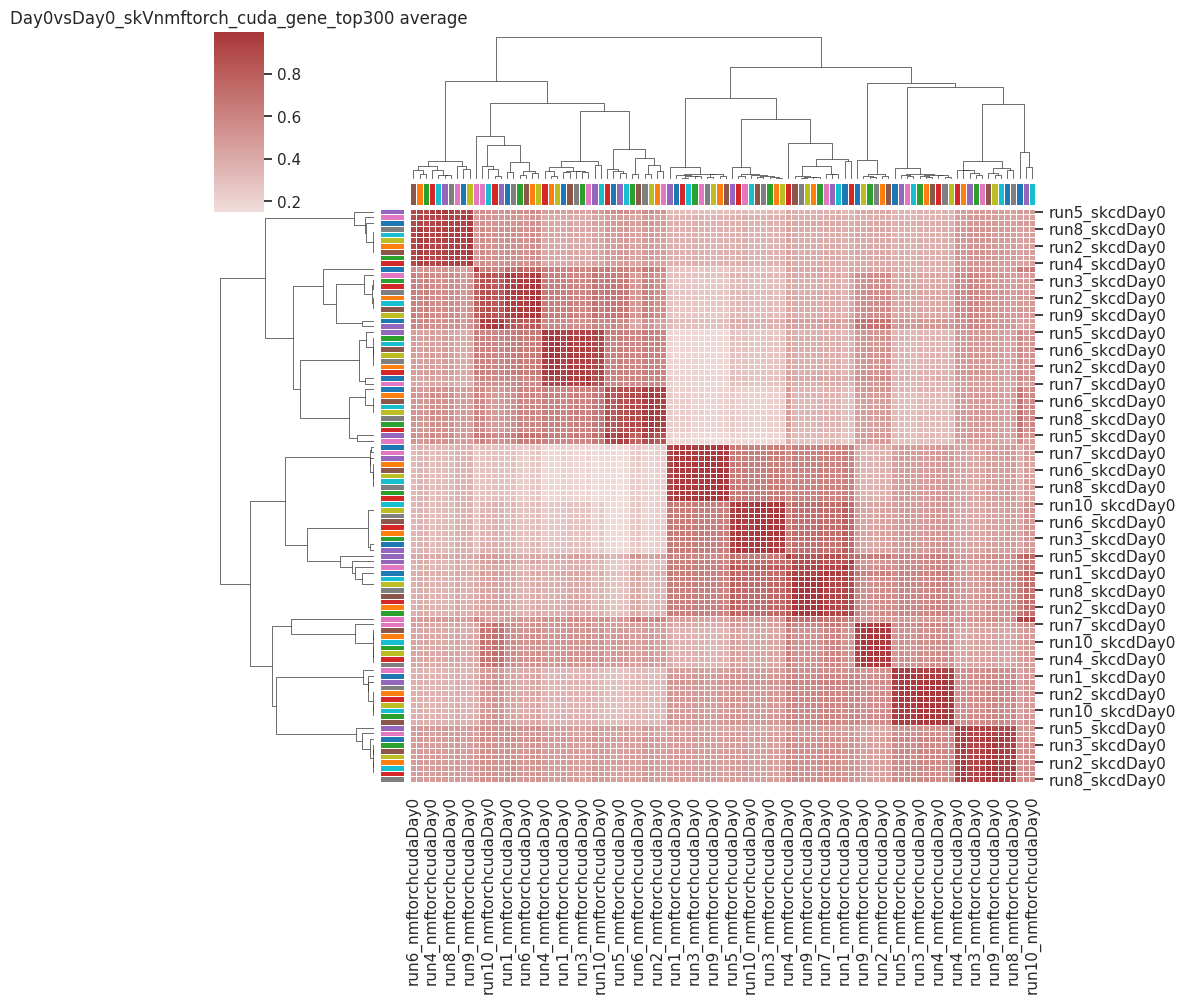

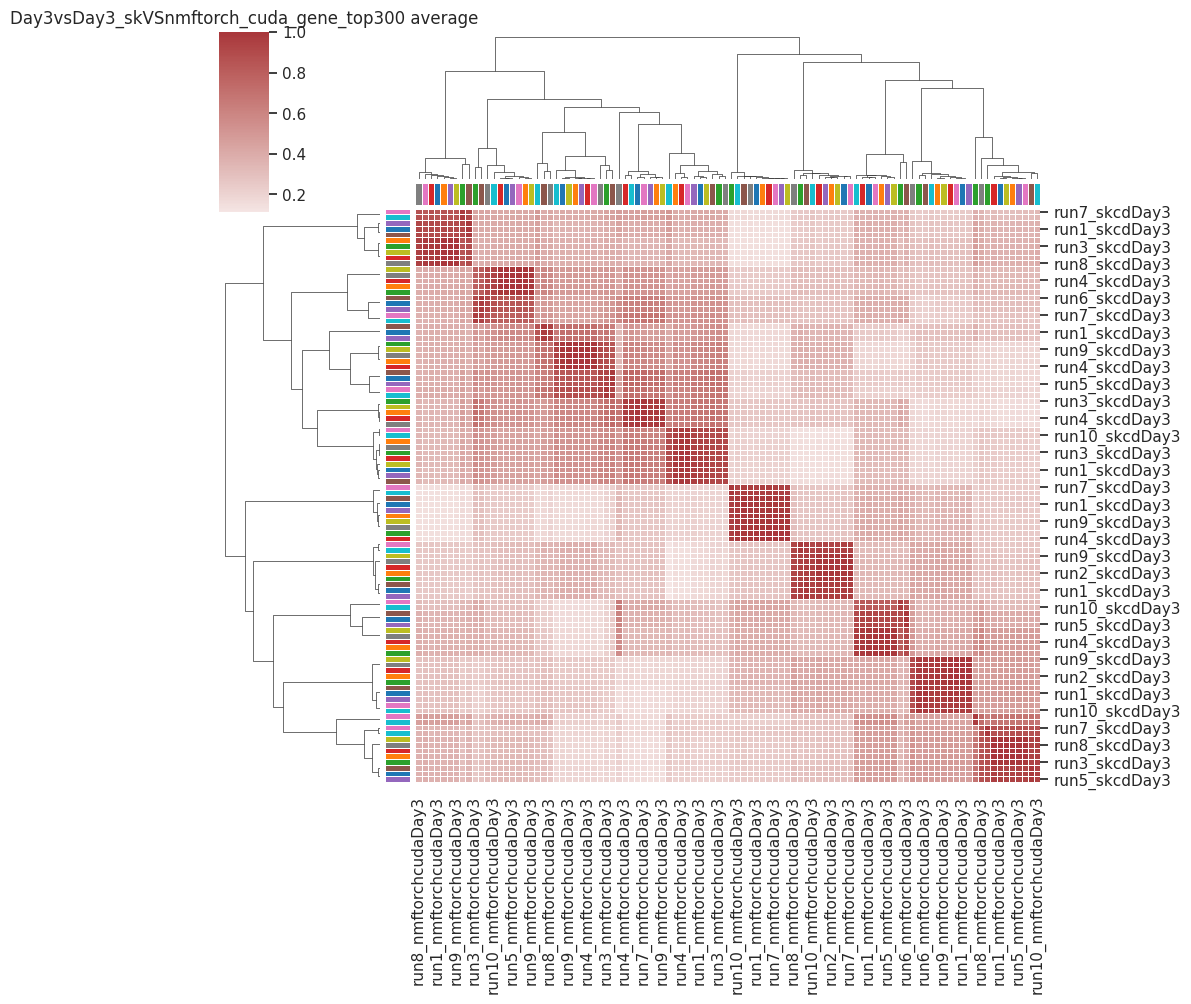

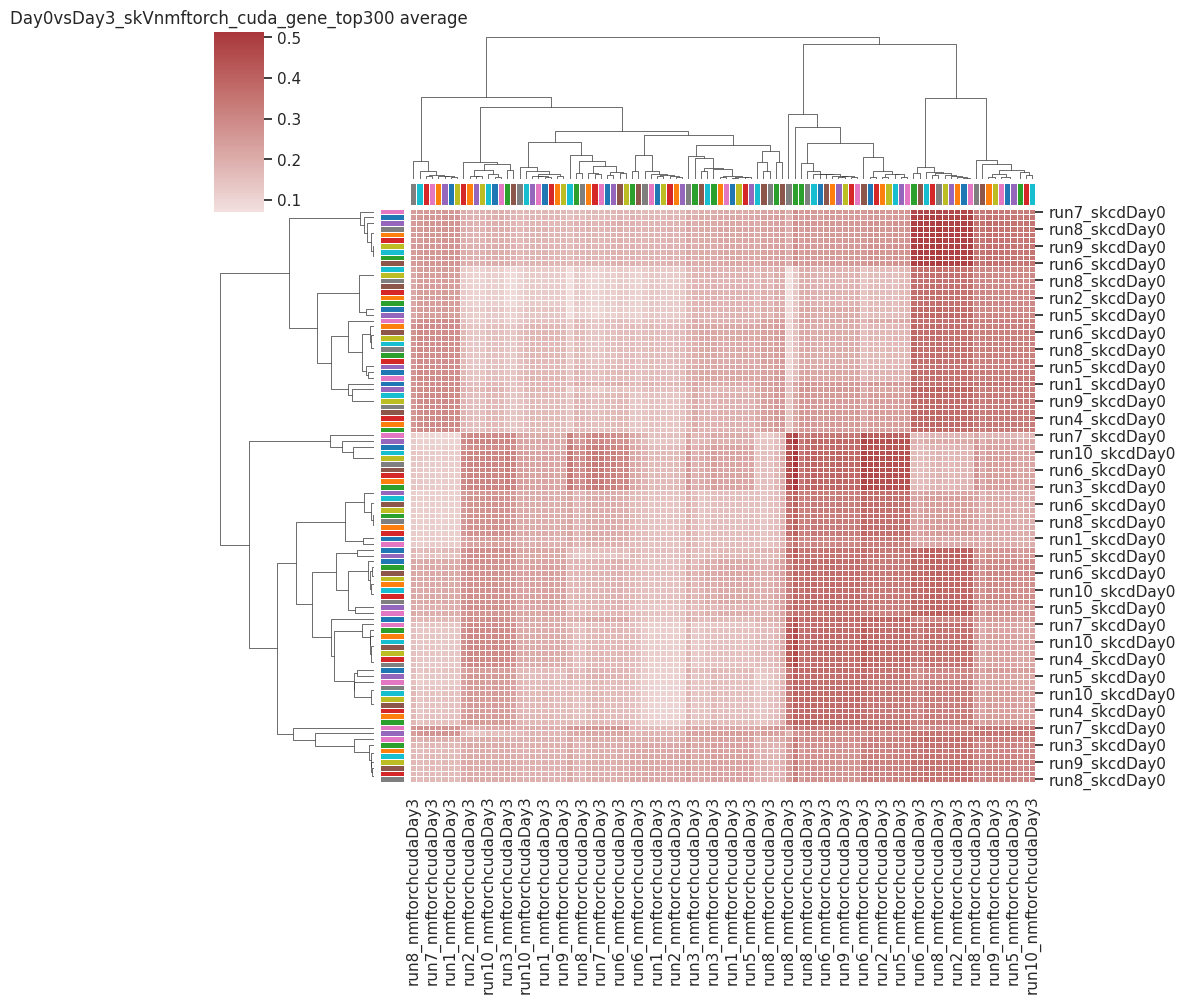

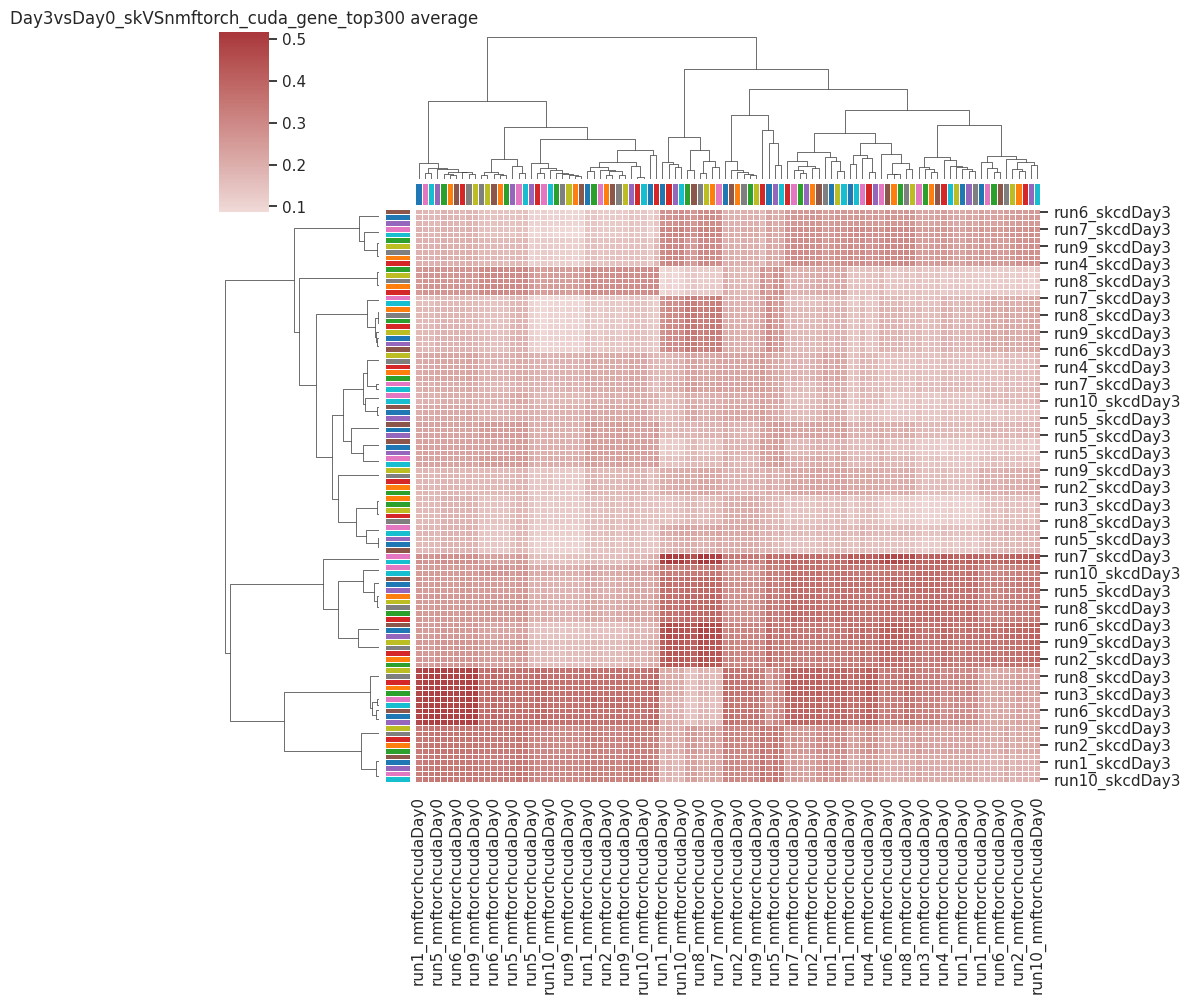

In [18]:
# D0 and D3 cells 

folder_name_input = "/oak/stanford/groups/engreitz/Users/ymo/NMF_re-inplementing/Results/NMF_benchmark_10_runs_random_seeds_D0+D3_7.30.25"
folder_name_output= "/oak/stanford/groups/engreitz/Users/ymo/NMF_re-inplementing/Results/NMF_correlation_top300_gene_7.30.25"

g_sk_cd_top300_D0 = within_package_overlap_cluster(folder_name_input, "H_sk_cd_K10_cell30907_Day0", folder_name_output, "H_sk_cd_K10_gene_cell30907_Day0_top300", adata.var, cluster_method = "average" )
g_sk_cd_top300_D3 = within_package_overlap_cluster(folder_name_input, "H_sk_cd_K10_cell30778_Day3", folder_name_output, "H_sk_cd_K10_gene_cell30907_Day0_top300", adata.var, cluster_method = "average" )
g_sk_cd_D0_top300_D3 = across_package_overlap_cluster(folder_name_input,  "H_sk_cd_K10_cell30907_Day0", "H_sk_cd_K10_cell30778_Day3", folder_name_output, "Day0vsDay3_gene_sk_cd_top300",  adata.var, cluster_method = "average" )

g_nmftorch_cuda_D0_top300 = within_package_overlap_cluster(folder_name_input, "H_nmftorch_cuda_K10_cell30907_Day0", folder_name_output, "H_nmftorch_cuda_K10_gene_cell30907_Day0_top300", adata.var, cluster_method = "average" )
g_nmftorch_cuda_D3_top300 = within_package_overlap_cluster(folder_name_input, "H_nmftorch_cuda_K10_cell30778_Day3", folder_name_output, "H_nmftorch_cuda_K10_gene_cell30778_Day3_top300", adata.var, cluster_method = "average" )
g_nmftorch_cuda_D0_D3_top300 = across_package_overlap_cluster(folder_name_input,  "H_nmftorch_cuda_K10_cell30907_Day0", "H_nmftorch_cuda_K10_cell30778_Day3", folder_name_output, "Day0vsDay3_gene_nmftorch_cuda_top300",  adata.var, cluster_method = "average" )

g_nmftorch_D0_sk_D0_top300 = across_package_overlap_cluster(folder_name_input,  "H_sk_cd_K10_cell30907_Day0", "H_nmftorch_cuda_K10_cell30907_Day0", folder_name_output, "Day0vsDay0_skVnmftorch_cuda_gene_top300",  adata.var, cluster_method = "average" )
g_nmftorch_D3_sk_D3_top300 = across_package_overlap_cluster(folder_name_input,  "H_sk_cd_K10_cell30778_Day3", "H_nmftorch_cuda_K10_cell30778_Day3", folder_name_output, "Day3vsDay3_skVSnmftorch_cuda_gene_top300",  adata.var, cluster_method = "average" )
g_sk_D0_nmftorch_D3_top300 = across_package_overlap_cluster(folder_name_input,  "H_sk_cd_K10_cell30907_Day0", "H_nmftorch_cuda_K10_cell30778_Day3", folder_name_output, "Day0vsDay3_skVnmftorch_cuda_gene_top300",  adata.var, cluster_method = "average" )
g_sk_D3_nmftorch_D0_top300 = across_package_overlap_cluster(folder_name_input,  "H_sk_cd_K10_cell30778_Day3", "H_nmftorch_cuda_K10_cell30907_Day0", folder_name_output, "Day3vsDay0_skVSnmftorch_cuda_gene_top300",  adata.var, cluster_method = "average" )

## Heatmap

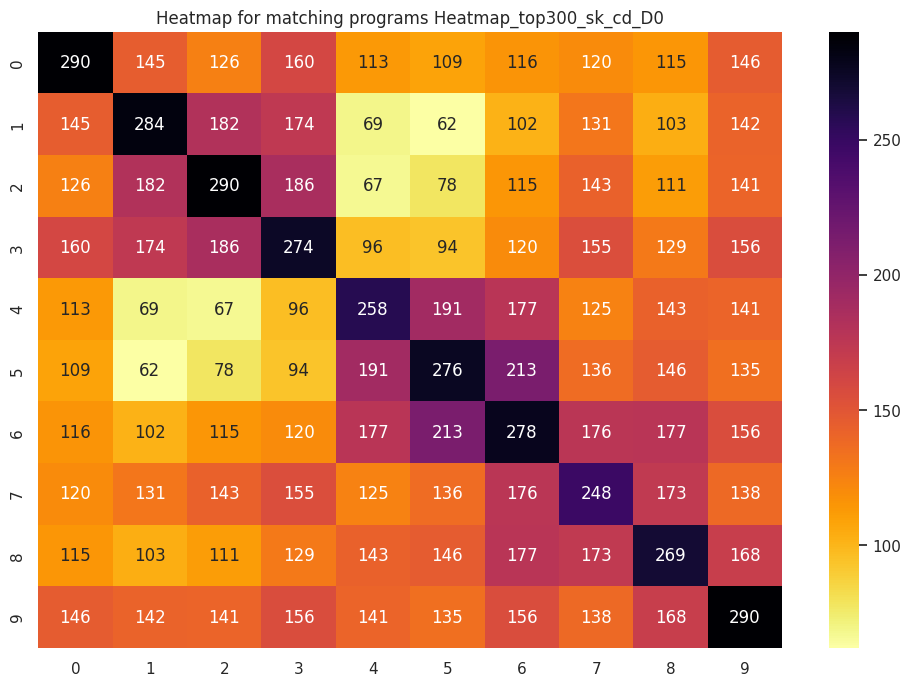

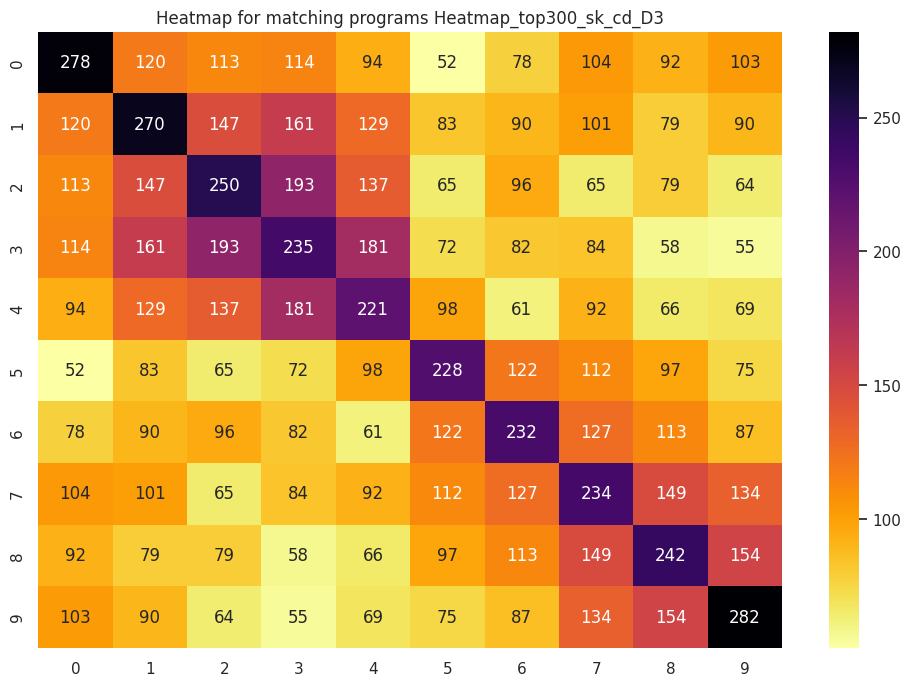

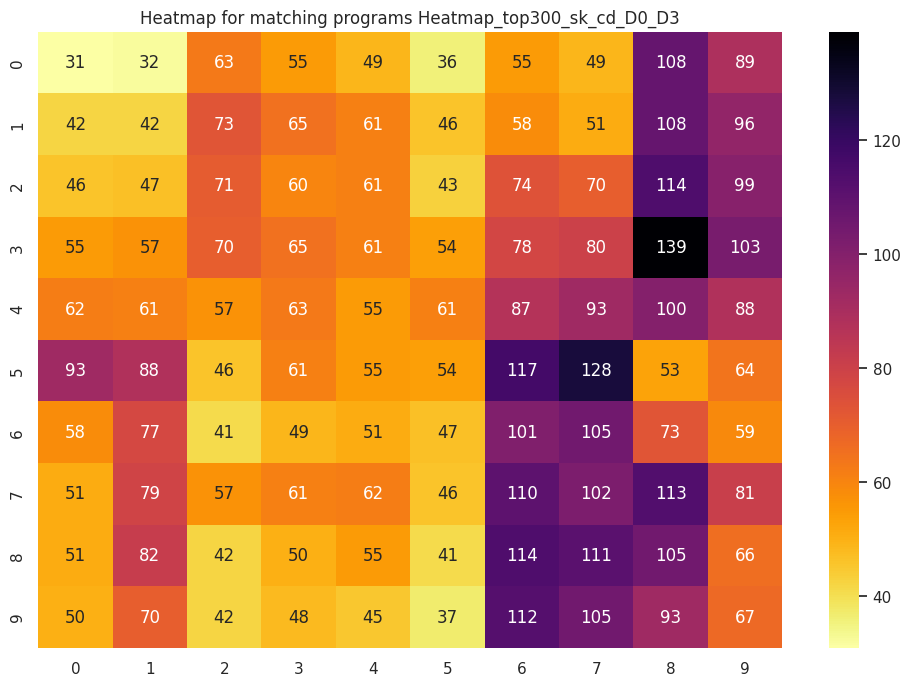

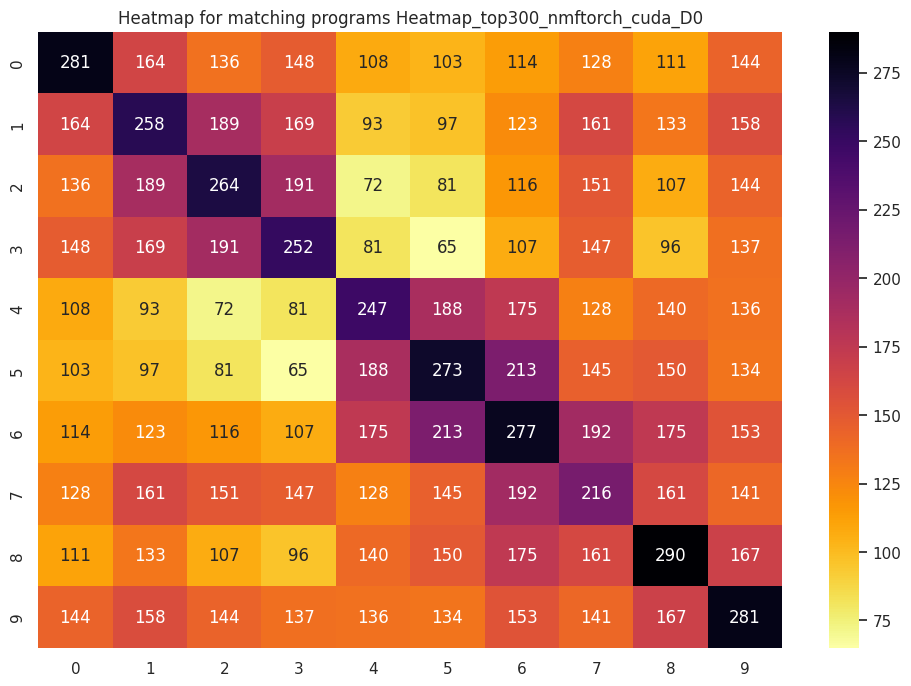

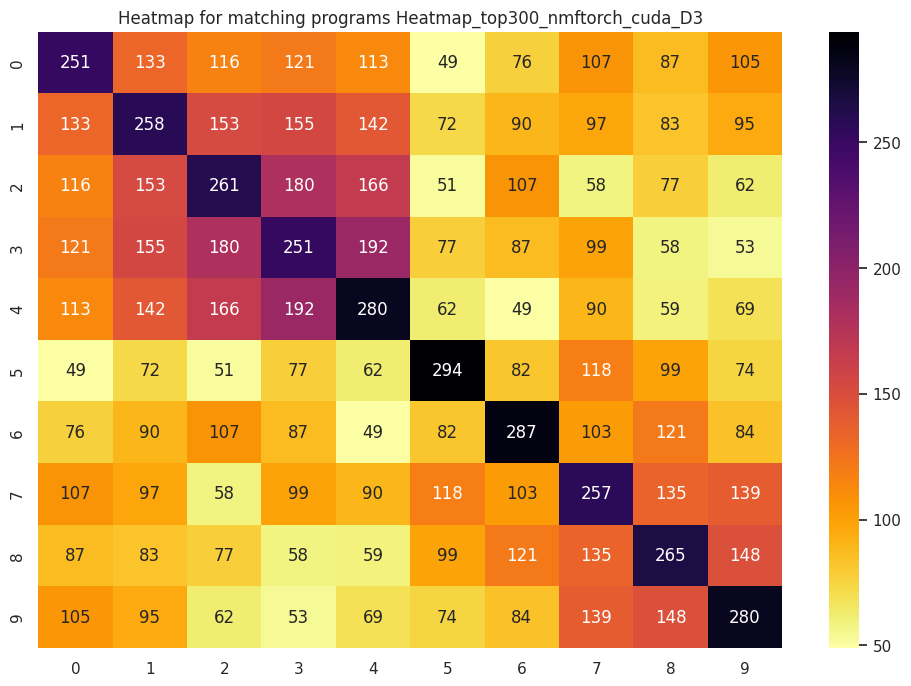

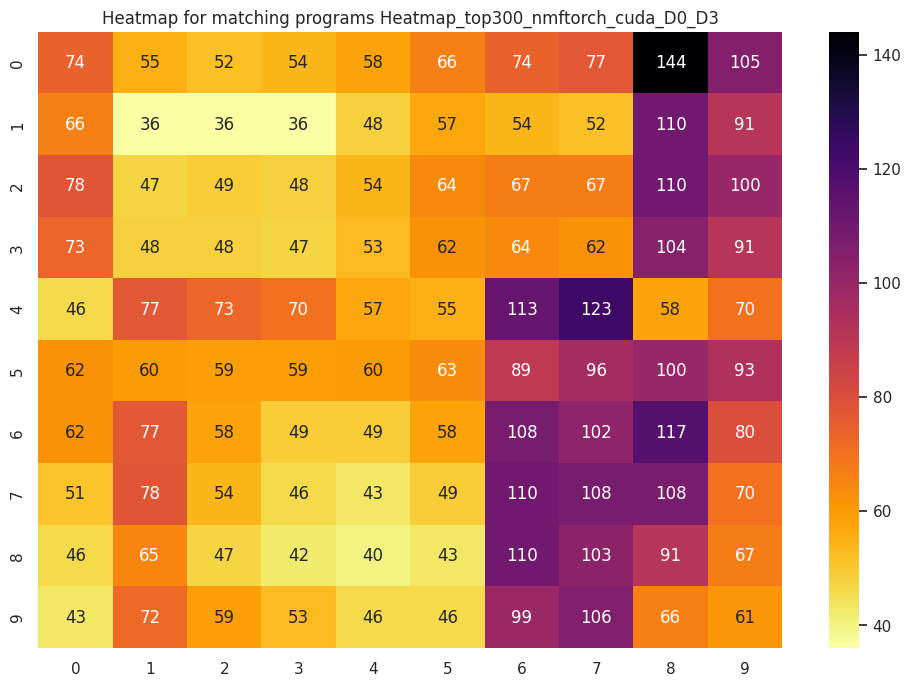

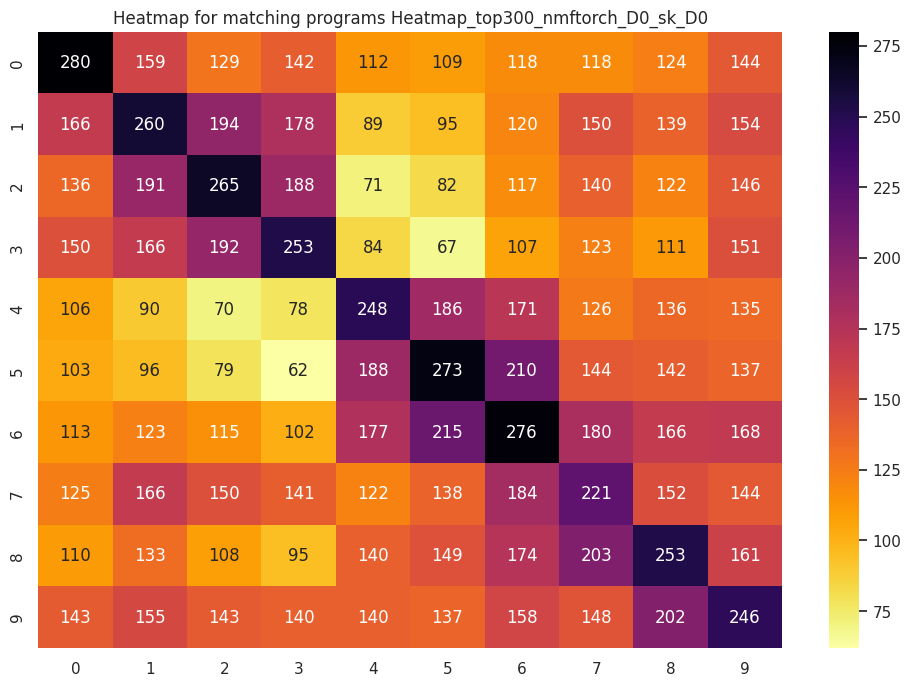

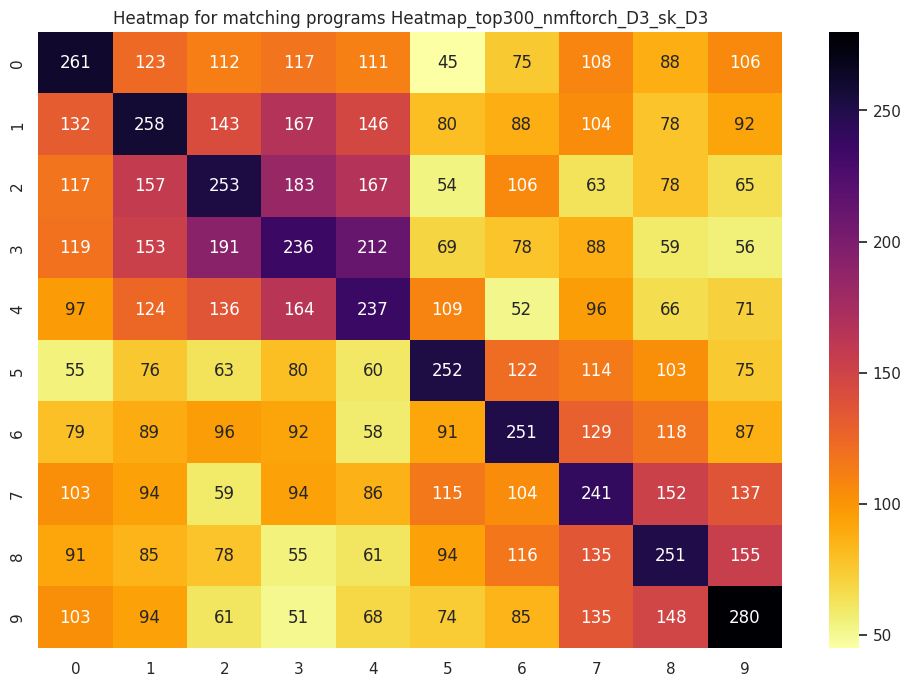

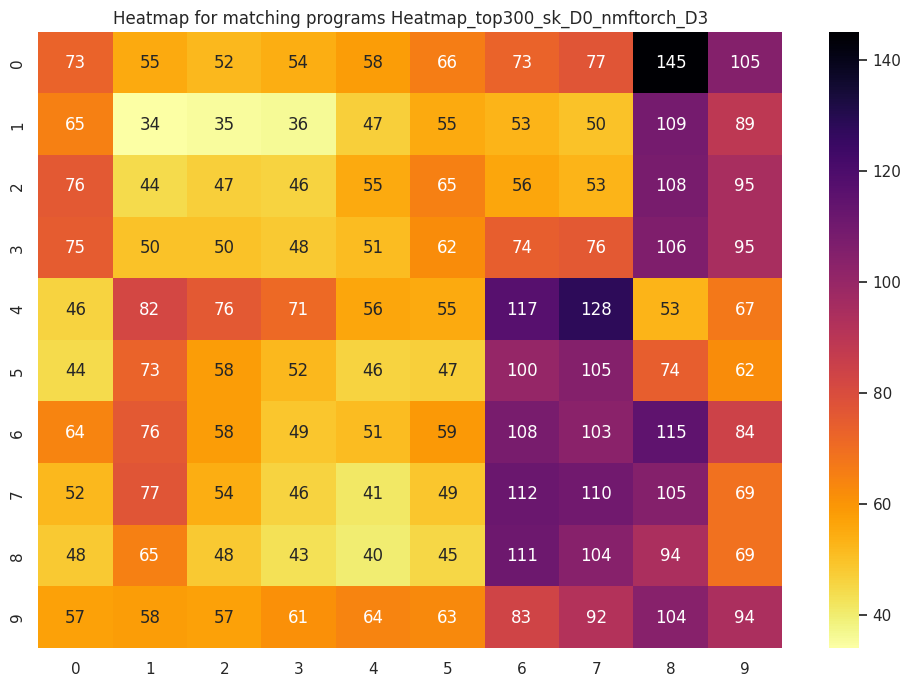

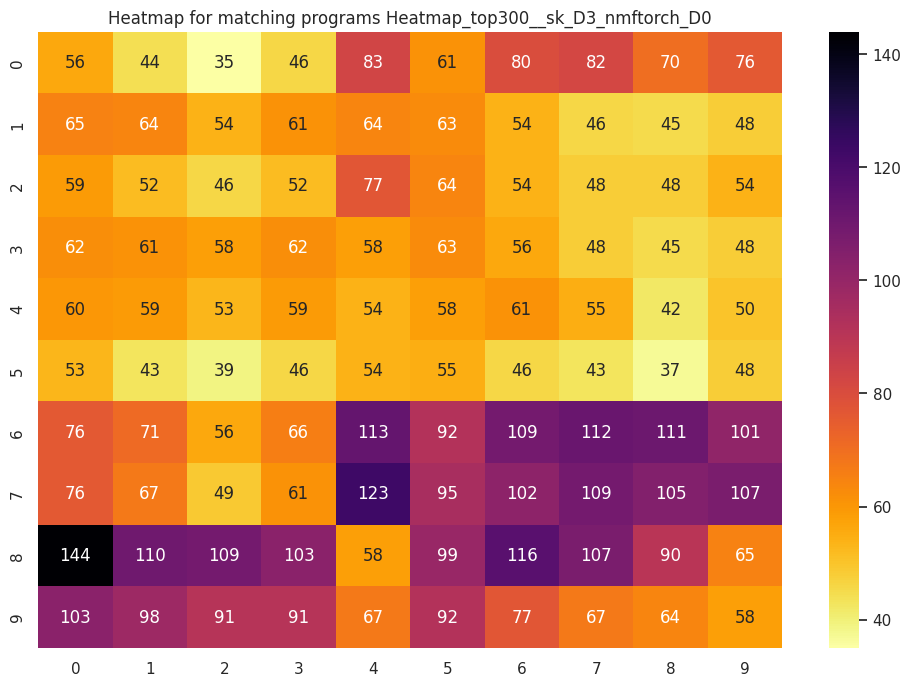

In [23]:
#graph_heatmap(g_nmftorch_cuda_top300, 10, 10, folder_name_results_figures, "Heatmap_top300_nmftorch_cuda", num_gene = 300, sorted = False)
#graph_heatmap(g_sk_cd_top300, 10, 10, folder_name_results_figures, "Heatmap_top300_sk_cd", num_gene = 300, sorted = False)
#graph_heatmap(g_combined_top300, 10, 10, folder_name_results_figures, "Heatmap_top300_skVSnmftorch", num_gene = 300, sorted = False)

graph_heatmap(g_sk_cd_top300_D0, 10, 10, folder_name_output, "Heatmap_top300_sk_cd_D0", num_gene = 300, sorted = False)
graph_heatmap(g_sk_cd_top300_D3, 10, 10, folder_name_output, "Heatmap_top300_sk_cd_D3", num_gene = 300, sorted = False)
graph_heatmap(g_sk_cd_D0_top300_D3, 10, 10, folder_name_output, "Heatmap_top300_sk_cd_D0_D3", num_gene = 300, sorted = False)

graph_heatmap(g_nmftorch_cuda_D0_top300, 10, 10, folder_name_output, "Heatmap_top300_nmftorch_cuda_D0", num_gene = 300, sorted = False)
graph_heatmap(g_nmftorch_cuda_D3_top300, 10, 10, folder_name_output, "Heatmap_top300_nmftorch_cuda_D3", num_gene = 300, sorted = False)
graph_heatmap(g_nmftorch_cuda_D0_D3_top300, 10, 10, folder_name_output, "Heatmap_top300_nmftorch_cuda_D0_D3", num_gene = 300, sorted = False)


graph_heatmap(g_nmftorch_D0_sk_D0_top300, 10, 10, folder_name_output, "Heatmap_top300_nmftorch_D0_sk_D0", num_gene = 300, sorted = False)
graph_heatmap(g_nmftorch_D3_sk_D3_top300, 10, 10, folder_name_output, "Heatmap_top300_nmftorch_D3_sk_D3", num_gene = 300, sorted = False)
graph_heatmap(g_sk_D0_nmftorch_D3_top300, 10, 10, folder_name_output, "Heatmap_top300_sk_D0_nmftorch_D3", num_gene = 300, sorted = False)
graph_heatmap(g_sk_D3_nmftorch_D0_top300, 10, 10, folder_name_output, "Heatmap_top300_sk_D3_nmftorch_D0", num_gene = 300, sorted = False)